In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

from utils.utils import reformat_transcript_id

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

## Load Data

In [5]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.genomic.pkl"
hela_genomic_df = pd.read_pickle(hela_genomic_df)
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         3  0.013685   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         3 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         3 -0.000000   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         3 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         3  0.011464   
...                          ...         ...     ...       ...       ...   
chrY:-:318660      chrY:-:318660    GTPBP6_1    True         4  0.000000   
chrY:-:318663      chrY:-:318663    GTPBP6_1    True         4 -0.000000   
chrY:-:318679      chrY:-:318679    GTPBP6_1    True         4 -0.000000   
chrY:-:318709      chrY:-:318709    GTPBP6_1    True         4 -0.000000   
chrY:-:318763      chrY:-:318763    GTPBP6_1    True         4 -0.000000   

           

In [6]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
hek_genomic_df = pd.read_pickle(hek_genomic_df)
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         3 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         3  0.016154   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         3 -0.000000   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         3 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         3  0.023575   
...                          ...         ...     ...       ...       ...   
chrY:-:341387      chrY:-:341387   PPP2R3B_1    True         8  0.000000   
chrY:-:341388      chrY:-:341388   PPP2R3B_1    True         8 -0.000000   
chrY:-:341389      chrY:-:341389   PPP2R3B_1    True         7  0.000000   
chrY:-:341391      chrY:-:341391   PPP2R3B_1    True         8  0.000000   
chrY:-:341395      chrY:-:341395   PPP2R3B_1    True         8  0.000000   

           

In [3]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
hela_df["transcript_id"] = hela_df["label_id"].str.split(":").str[0]
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(np.int32)

print(hela_df)

                       label_id  pm6a       dom  count_all  count_pos  \
609           ENST00000260952:6  -0.0  0.054009         57          0   
610           ENST00000260952:7  -0.0  0.020290         59          0   
611          ENST00000260952:14  -0.0  0.000118         89          0   
612          ENST00000260952:24  -0.0  0.032300        161          0   
613          ENST00000260952:31  -0.0  0.002599        202          0   
...                         ...   ...       ...        ...        ...   
107059406  ENST00000815204:1309   0.0  0.000000         27          0   
107059407  ENST00000815204:1323  -0.0  0.025979         27          0   
107059408  ENST00000815204:1325  -0.0  0.008778         27          0   
107059409  ENST00000815204:1328   0.0  0.000000         27          0   
107059410  ENST00000815204:1330   0.0  0.000000         27          0   

           kl_div_neg  kl_div_pos  logsum_1_p_pos    transcript_id   pos  
609         42.768013    2.441718             0.

In [7]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
hek_df["transcript_id"] = hek_df["label_id"].str.split(":").str[0]
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(np.int32)

print(hek_df)

                       label_id      pm6a       dom  count_all  count_pos  \
26238         XM_047432108.1:28  0.000000  0.000000         20          0   
26239         XM_047432108.1:29  0.000000  0.000000         20          0   
26240         XM_047432108.1:34  0.000000  0.000000         20          0   
26241         XM_047432108.1:38  0.000000  0.000000         23          0   
26242         XM_047432108.1:40  0.000000  0.000000         24          0   
...                         ...       ...       ...        ...        ...   
122685177  ENST00000580243:5593 -0.000000  0.003323        116          0   
122685178  ENST00000580243:5594 -0.000000  0.004047        116          0   
122685179  ENST00000580243:5598 -0.000000  0.010590        114          0   
122685180  ENST00000580243:5600 -0.000000  0.004701        114          0   
122685181  ENST00000580243:5604  0.034858  0.016067         97          1   

           kl_div_neg  kl_div_pos  logsum_1_p_pos    transcript_id   pos  


In [8]:
hela_df.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.pkl")
hek_df.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.pkl")

In [50]:
hek_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")
hela_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.pileup.label.pkl.genomic.pkl")

In [51]:
print(hek_label)

                       genome_id  depth     5mer  coding  drach  isoforms
genome_id                                                                
chr10:+:1000681  chr10:+:1000681    519  [GTAGA]    True  False         3
chr10:+:1000683  chr10:+:1000683    519  [AGACA]    True   True         3
chr10:+:1000685  chr10:+:1000685    520  [ACACT]    True  False         3
chr10:+:1000694  chr10:+:1000694    519  [GGATC]    True  False         3
chr10:+:1000701  chr10:+:1000701    519  [GGACC]    True   True         3
...                          ...    ...      ...     ...    ...       ...
chrY:-:5337902    chrY:-:5337902      1  [GAAAA]   False  False         1
chrY:-:5337903    chrY:-:5337903      1  [GGAAA]   False  False         1
chrY:-:5337907    chrY:-:5337907      1  [ACAGG]   False  False         1
chrY:-:5337909    chrY:-:5337909      1  [CAACA]   False  False         1
chrY:-:5337910    chrY:-:5337910      1  [CCAAC]   False  False         1

[26095811 rows x 6 columns]


In [52]:
hek_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.pileup.label.pkl.transcriptome.pkl")
hela_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.pileup.label.pkl.transcriptome.pkl")

In [13]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")
print(hek_dorado_df)

                       genome_id      gene_symbol       dom  count_dom  coding
genome_id                                                                     
chr10:+:1000680  chr10:+:1000680           GTPBP4  0.285714          7    True
chr10:+:1000681  chr10:+:1000681           GTPBP4  0.008457        473    True
chr10:+:1000683  chr10:+:1000683           GTPBP4  0.002024        494    True
chr10:+:1000685  chr10:+:1000685           GTPBP4  0.017241        464    True
chr10:+:1000688  chr10:+:1000688           GTPBP4  1.000000          1    True
...                          ...              ...       ...        ...     ...
chrY:-:5337897    chrY:-:5337897  ENSG00000235001  0.000000          1   False
chrY:-:5337900    chrY:-:5337900  ENSG00000235001  0.000000          1   False
chrY:-:5337901    chrY:-:5337901  ENSG00000235001  0.000000          1   False
chrY:-:5337902    chrY:-:5337902  ENSG00000235001  0.000000          1   False
chrY:-:5337903    chrY:-:5337903  ENSG00000235001  0

In [20]:
hek_label = hek_label.reset_index(drop=True)
hek_genomic_df = hek_genomic_df.reset_index(drop=True)
hek_dorado_df = hek_dorado_df.reset_index(drop=True)
hek_transcript_label = hek_transcript_label.reset_index(drop=True)

hela_label = hela_label.reset_index(drop=True)
hela_genomic_df = hela_genomic_df.reset_index(drop=True)
hela_transcript_label = hela_transcript_label.reset_index(drop=True)

In [134]:
print(hela_transcript_label)

             transcript_id   pos base  depth   5mer  coding  drach  \
0          ENST00000164133     6    A      8  TCATC    True  False   
1          ENST00000164133    12    A     14  TGAGC    True  False   
2          ENST00000164133    15    A     16  GCAGC    True  False   
3          ENST00000164133    40    A     29  GCACG    True  False   
4          ENST00000164133    44    A     30  GGAGC    True  False   
...                    ...   ...  ...    ...    ...     ...    ...   
109271066      XR_951179.3  2095    A      4  ATAAA   False  False   
109271067      XR_951179.3  2096    A      4  TAAAA   False  False   
109271068      XR_951179.3  2097    A      4  AAAAG   False  False   
109271069      XR_951179.3  2098    A      4  AAAGG   False  False   
109271070      XR_951179.3  2101    A      4  GGACC   False   True   

                     label_id       gene_id    chr strand         genome_id  
0           ENST00000164133:6       PPP2R5B  chr11      +  chr11:+:64924694  
1  

In [21]:
hek_fdr_threshold = 0.61
hela_fdr_threshold = 0.64

hela_genomic_df_m6a = hela_genomic_df[hela_genomic_df["pm6a"] > hela_fdr_threshold].copy()
hek_genomic_df_m6a = hek_genomic_df[hek_genomic_df["pm6a"] > hek_fdr_threshold].copy()

In [22]:
dorado_f1_threshold = 0.59

airna_arr = hek_genomic_df[(hek_genomic_df["pm6a"] >= hek_fdr_threshold) & (hek_genomic_df["count_all"] >= 20)]["genome_id"].unique()
dorado_arr = hek_dorado_df[(hek_dorado_df["dom"] >= dorado_f1_threshold) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].unique()

## Venn

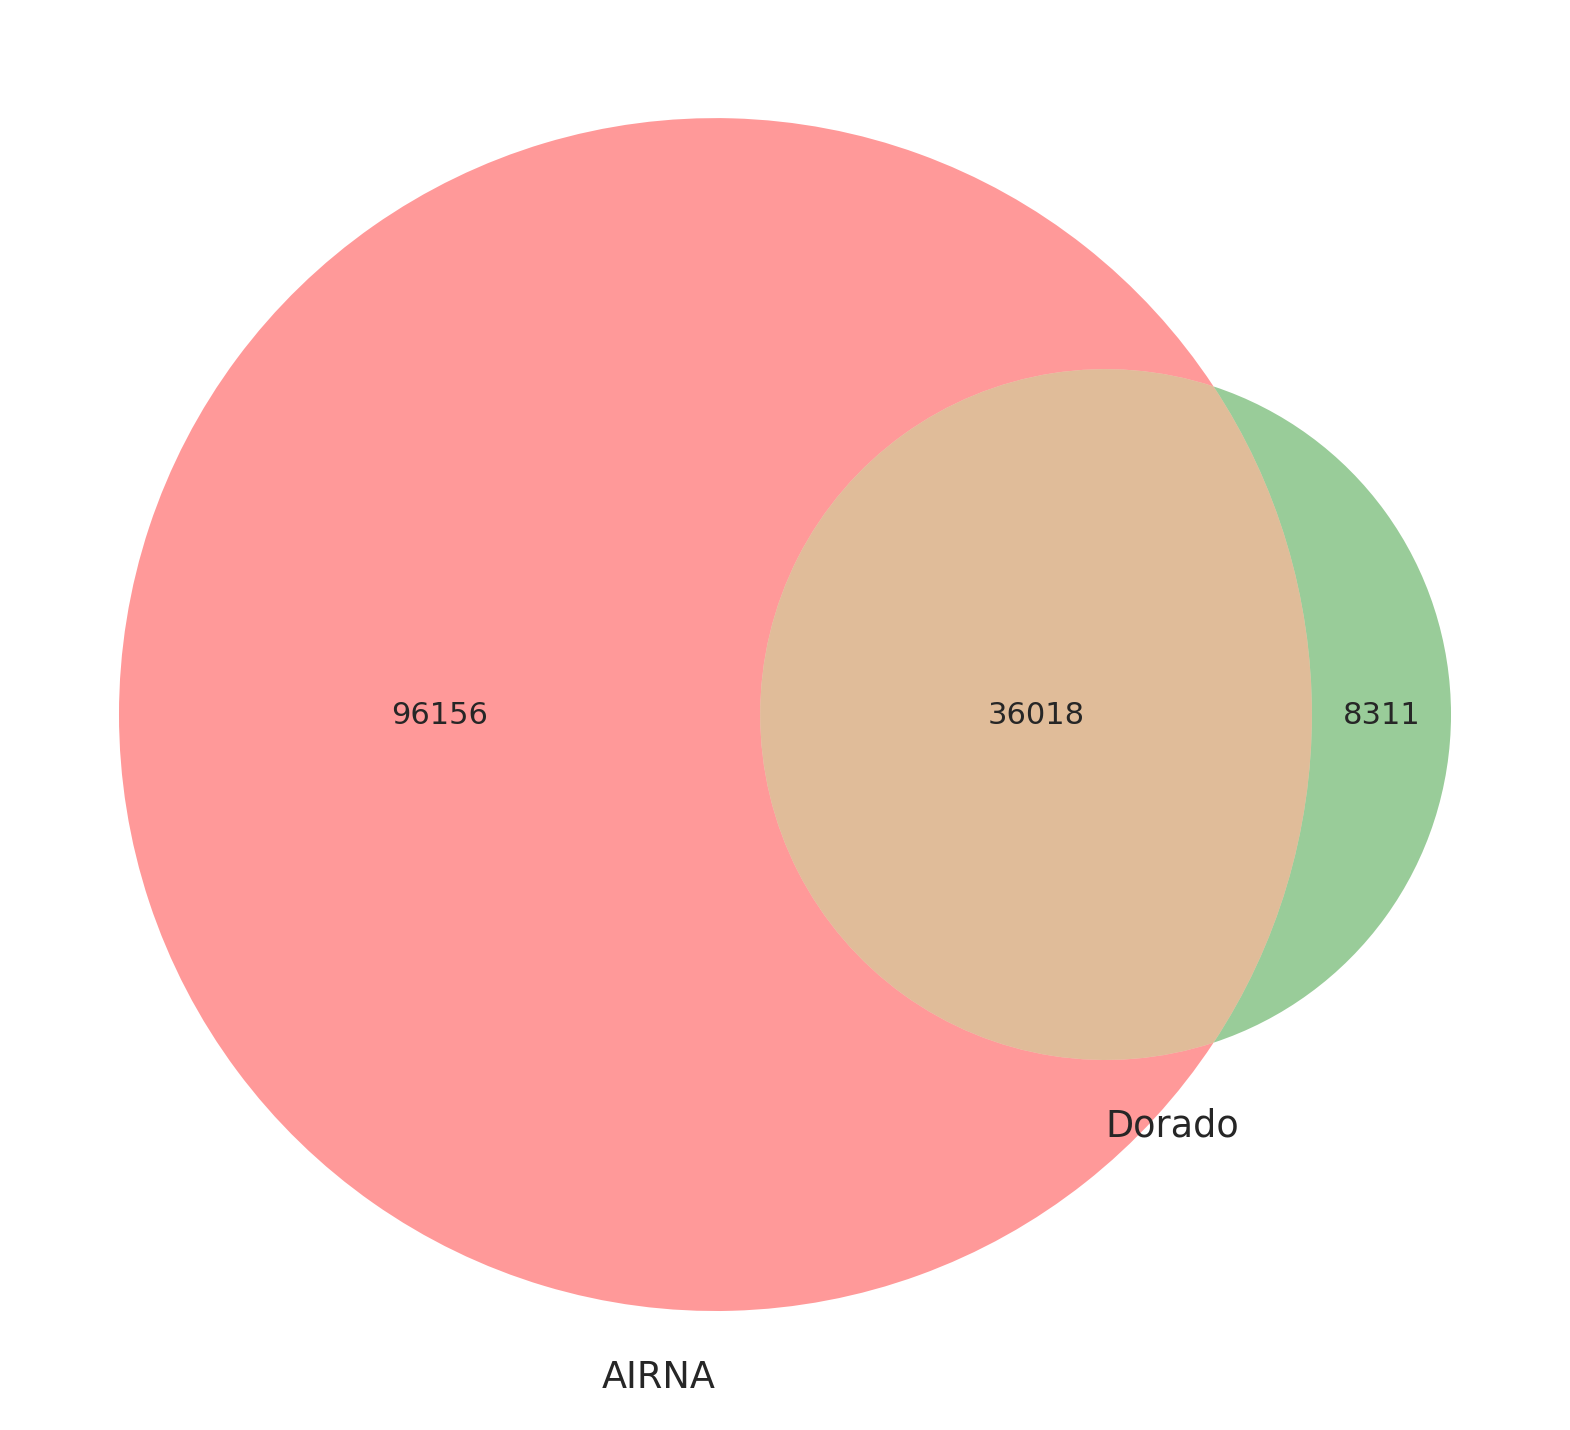

In [23]:
## Plot Venn
import matplotlib_venn as venn
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
## count
venn.venn2([set(airna_arr), set(dorado_arr)], set_labels=("AIRNA", "Dorado"))

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/venn.pdf", format="pdf")
plt.show()


## Pie

In [30]:
hek_eval = hek_genomic_df_m6a[["genome_id","gene_symbol","pm6a","dom","count_all"]].reset_index(drop=True).merge(hek_label, on="genome_id", how="left")
print(hek_eval[hek_eval["drach"].isna()])

Empty DataFrame
Columns: [genome_id, gene_symbol, pm6a, dom, count_all, depth, 5mer, coding, drach, isoforms]
Index: []


In [34]:
hela_eval = hela_genomic_df_m6a[["genome_id","gene_symbol","pm6a","dom","count_all"]].reset_index(drop=True).merge(hela_label, on="genome_id", how="left")

In [35]:
print(len(hek_eval), len(hela_eval))

132174 110086


108050 10108 12587 1429
[0.81748301 0.07647495 0.09523053 0.01081151]


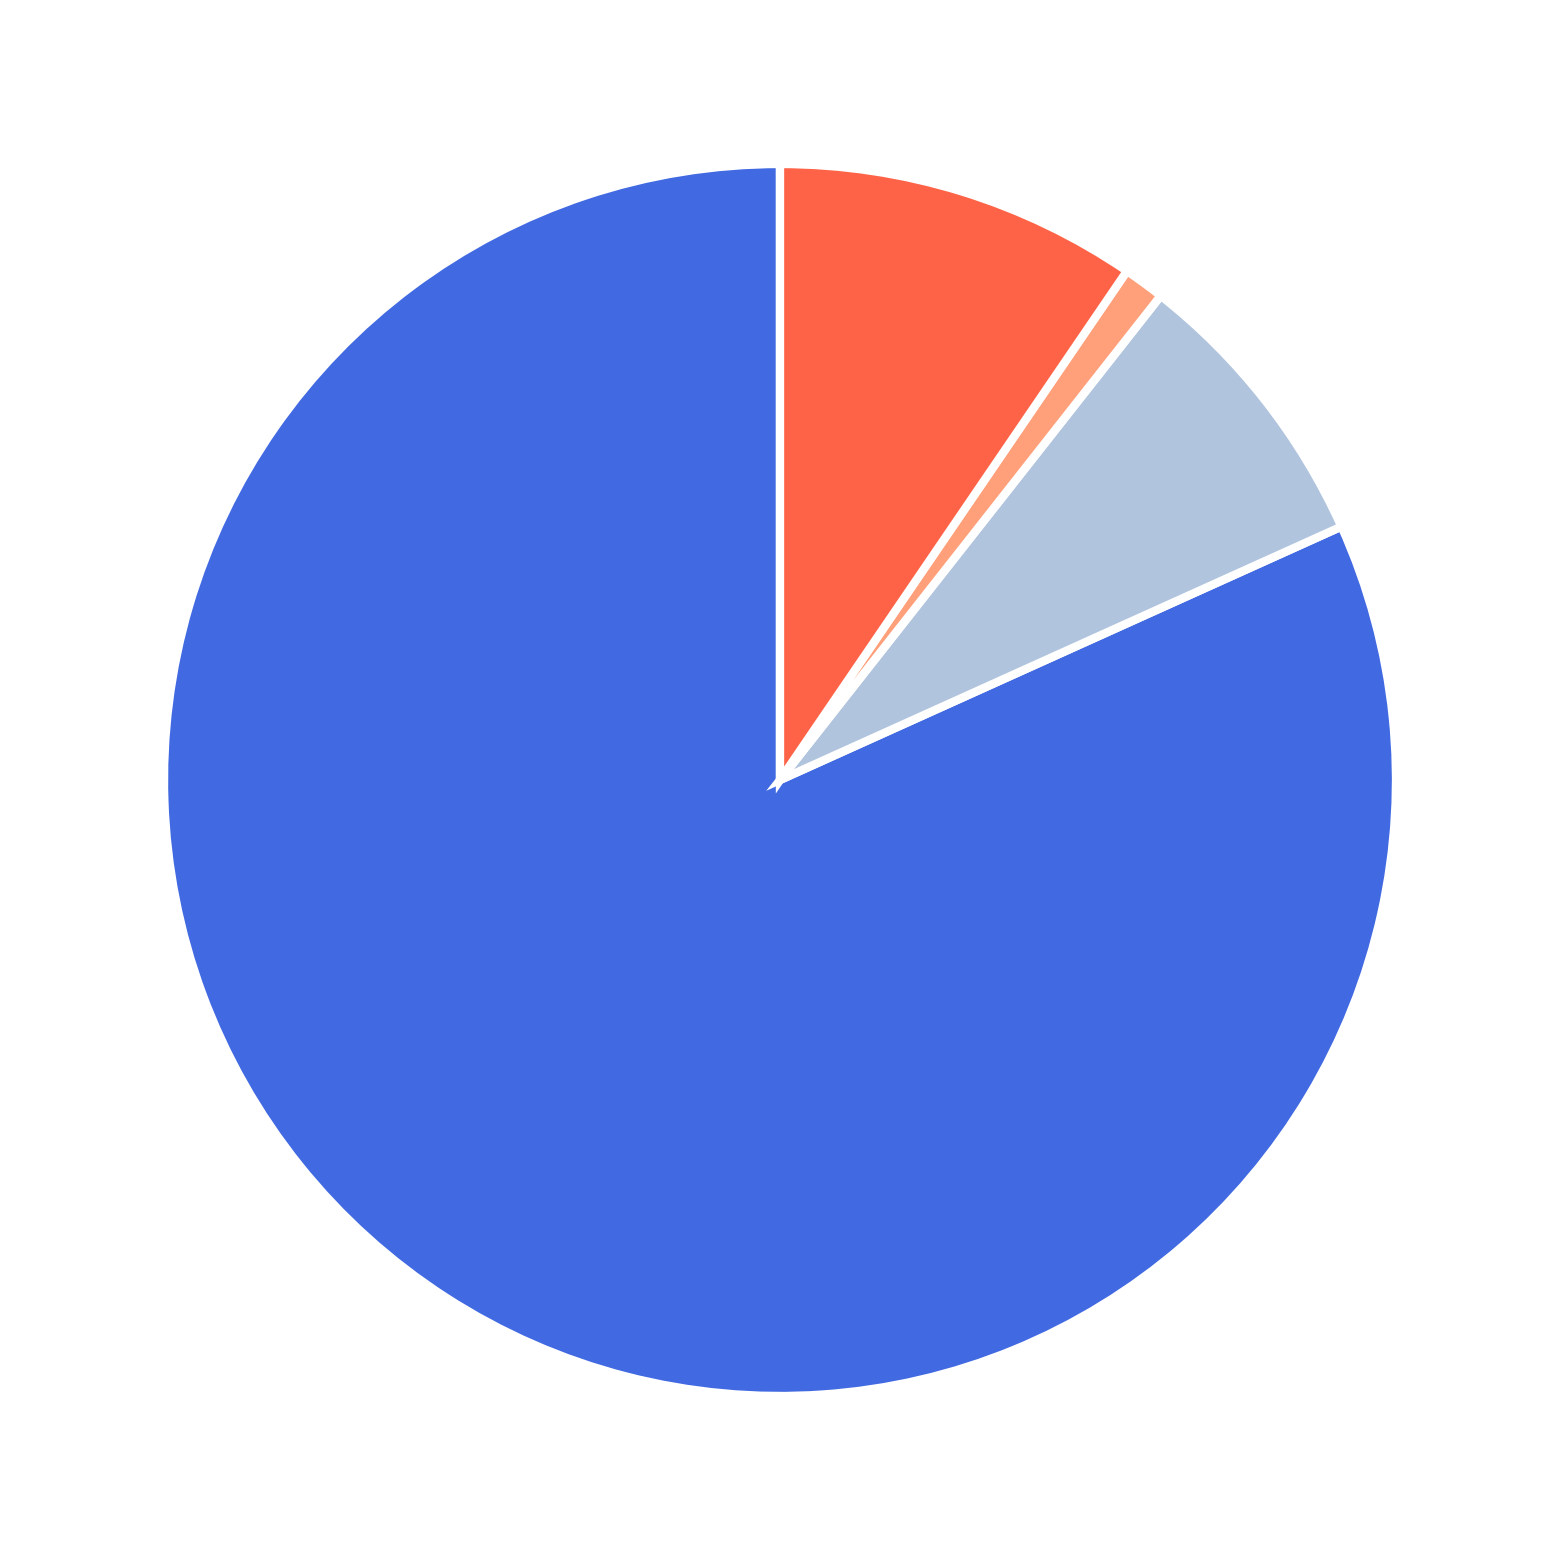

In [32]:
m6a_df = hek_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HEK.pdf", format="pdf")
plt.show()


91006 7899 10127 1054
[0.82668096 0.07175299 0.09199172 0.00957433]


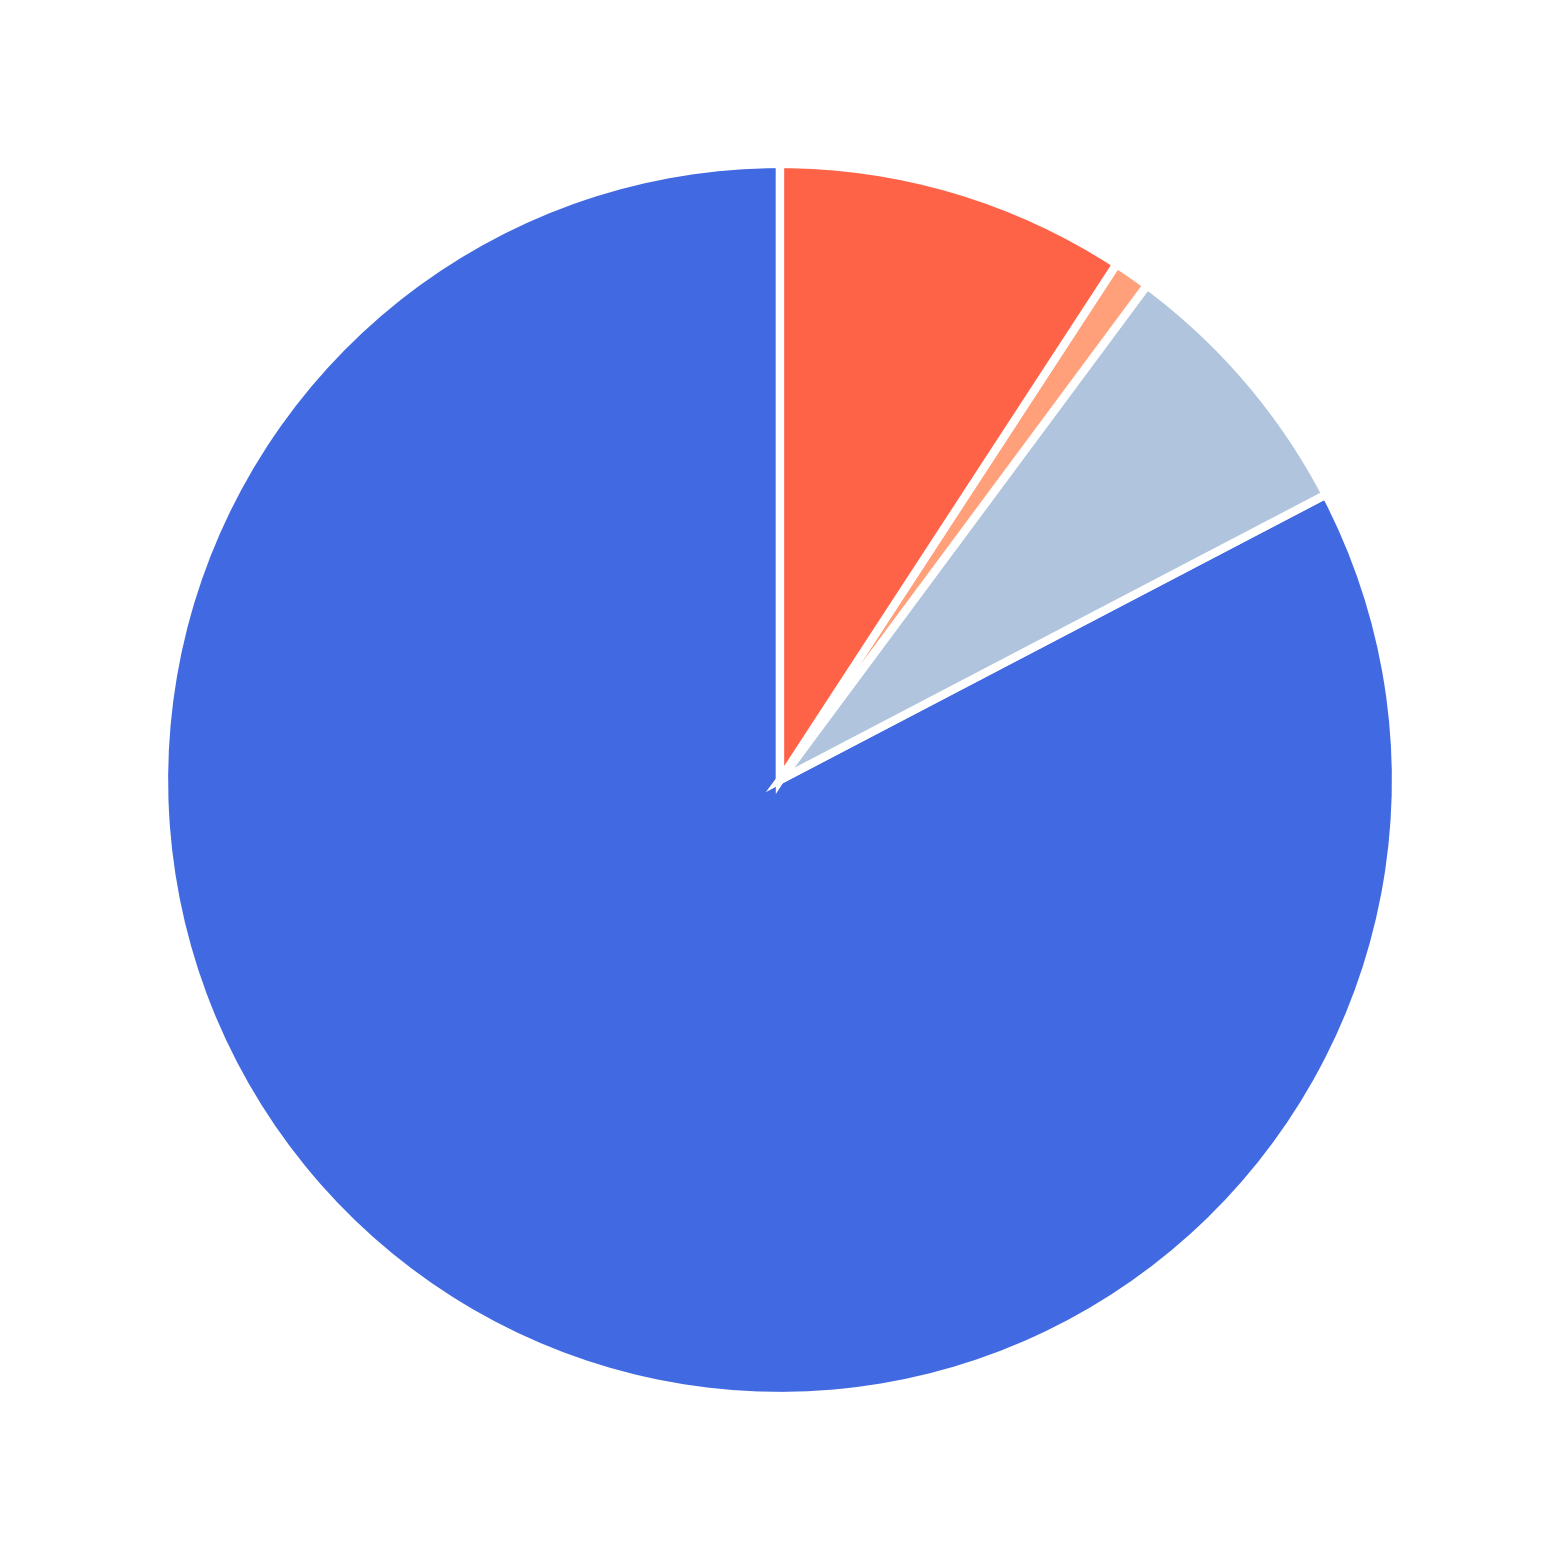

In [36]:
m6a_df = hela_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HeLa.pdf", format="pdf")
plt.show()
        

## 5mer motif

In [37]:
hek_eval_5mer = hek_eval.copy()
hek_eval_5mer = hek_eval_5mer.explode("5mer")
print(hek_eval_5mer)

                genome_id gene_symbol      pm6a       dom  count_all  depth  \
0       chr10:+:100363097         SCD  0.860140  0.181485       3825   3933   
1       chr10:+:100363423         SCD  0.767349  0.257288       4035   4155   
2       chr10:+:100364512         SCD  1.595091  0.354627       3040   3154   
3       chr10:+:100364569         SCD  0.875707  0.206898       3101   3184   
4       chr10:+:100381333    OLMALINC  0.966759  0.187965        143    145   
...                   ...         ...       ...       ...        ...    ...   
132169      chrY:-:304809    GTPBP6_1  2.436634  0.591496        194    201   
132170      chrY:-:305068    GTPBP6_1  0.935017  0.190863        195    196   
132171      chrY:-:334253   PPP2R3B_1  2.278427  0.457463         33     41   
132172      chrY:-:334292   PPP2R3B_1  1.519949  0.364753         38     40   
132173      chrY:-:334412   PPP2R3B_1  0.672721  0.111224         40     40   

         5mer  coding  drach  isoforms  
0       GA

In [38]:
hela_eval_5mer = hela_eval.copy()
hela_eval_5mer = hela_eval_5mer.explode("5mer")
print(hela_eval_5mer)

                genome_id gene_symbol      pm6a       dom  count_all  depth  \
0       chr10:+:100363097         SCD  0.687423  0.144393       6169   6340   
1       chr10:+:100363423         SCD  0.706717  0.213923       6484   6681   
2       chr10:+:100364512         SCD  1.439401  0.305213       3942   4051   
3       chr10:+:100364569         SCD  0.771271  0.168614       3985   4077   
4       chr10:+:100381589    OLMALINC  1.197137  0.245445         47     51   
...                   ...         ...       ...       ...        ...    ...   
110081     chrY:-:2489898     ZBED1_1  2.209690  0.564888         60     60   
110082     chrY:-:2490396     ZBED1_1  0.799202  0.153683         52     56   
110083      chrY:-:304777    GTPBP6_1  2.453871  0.655902         85     89   
110084      chrY:-:304809    GTPBP6_1  2.560760  0.589503         87     89   
110085      chrY:-:305068    GTPBP6_1  0.933694  0.166246         85     87   

         5mer  coding  drach  isoforms  
0       GA

In [39]:
def drach_ed(seq):
    ed = 0
    if not seq[0] in ["A", "G", "T", "U"]:
        ed += 1
    if not seq[1] in ["G", "A"]:
        ed += 1
    if not seq[2] == "A":
        ed += 1
    if not seq[3] == "C":
        ed += 1
    if not seq[4] in ["A", "C", "T", "U"]:
        ed += 1
    return ed


In [40]:
hek_eval_5mer["drach_ed"] = hek_eval_5mer["5mer"].apply(drach_ed)
print(hek_eval_5mer)

                genome_id gene_symbol      pm6a       dom  count_all  depth  \
0       chr10:+:100363097         SCD  0.860140  0.181485       3825   3933   
1       chr10:+:100363423         SCD  0.767349  0.257288       4035   4155   
2       chr10:+:100364512         SCD  1.595091  0.354627       3040   3154   
3       chr10:+:100364569         SCD  0.875707  0.206898       3101   3184   
4       chr10:+:100381333    OLMALINC  0.966759  0.187965        143    145   
...                   ...         ...       ...       ...        ...    ...   
132169      chrY:-:304809    GTPBP6_1  2.436634  0.591496        194    201   
132170      chrY:-:305068    GTPBP6_1  0.935017  0.190863        195    196   
132171      chrY:-:334253   PPP2R3B_1  2.278427  0.457463         33     41   
132172      chrY:-:334292   PPP2R3B_1  1.519949  0.364753         38     40   
132173      chrY:-:334412   PPP2R3B_1  0.672721  0.111224         40     40   

         5mer  coding  drach  isoforms  drach_ed  


In [41]:
print(hek_eval_5mer["drach_ed"].value_counts())

drach_ed
0    118207
1     13543
2       544
3       143
4        40
Name: count, dtype: int64


In [42]:
print(hek_eval_5mer[hek_eval_5mer["drach_ed"] == 4]["5mer"].value_counts())

5mer
CCATG    27
CCAGG     7
CTATG     2
CCANN     1
CCAAG     1
CTAGG     1
CTAAG     1
Name: count, dtype: int64


In [43]:
import re

     5mer  count
0   GGACT  20766
1   GGACA  16549
2   GAACT  13884
3   AGACT  13696
4   GGACC  10986
5   TGACT   9763
6   AAACT   8288
7   AGACA   6166
8   GAACA   5263
9   GGACG   4268
10  AGACC   2821
11  TGACA   2546
12  GAACC   2373
13  GGATT   2299
14  TAACT   2014
15  AAACA   1501
16  GTACT   1194
17  AGACG    938
18  TGACC    824
19  GAACG    631


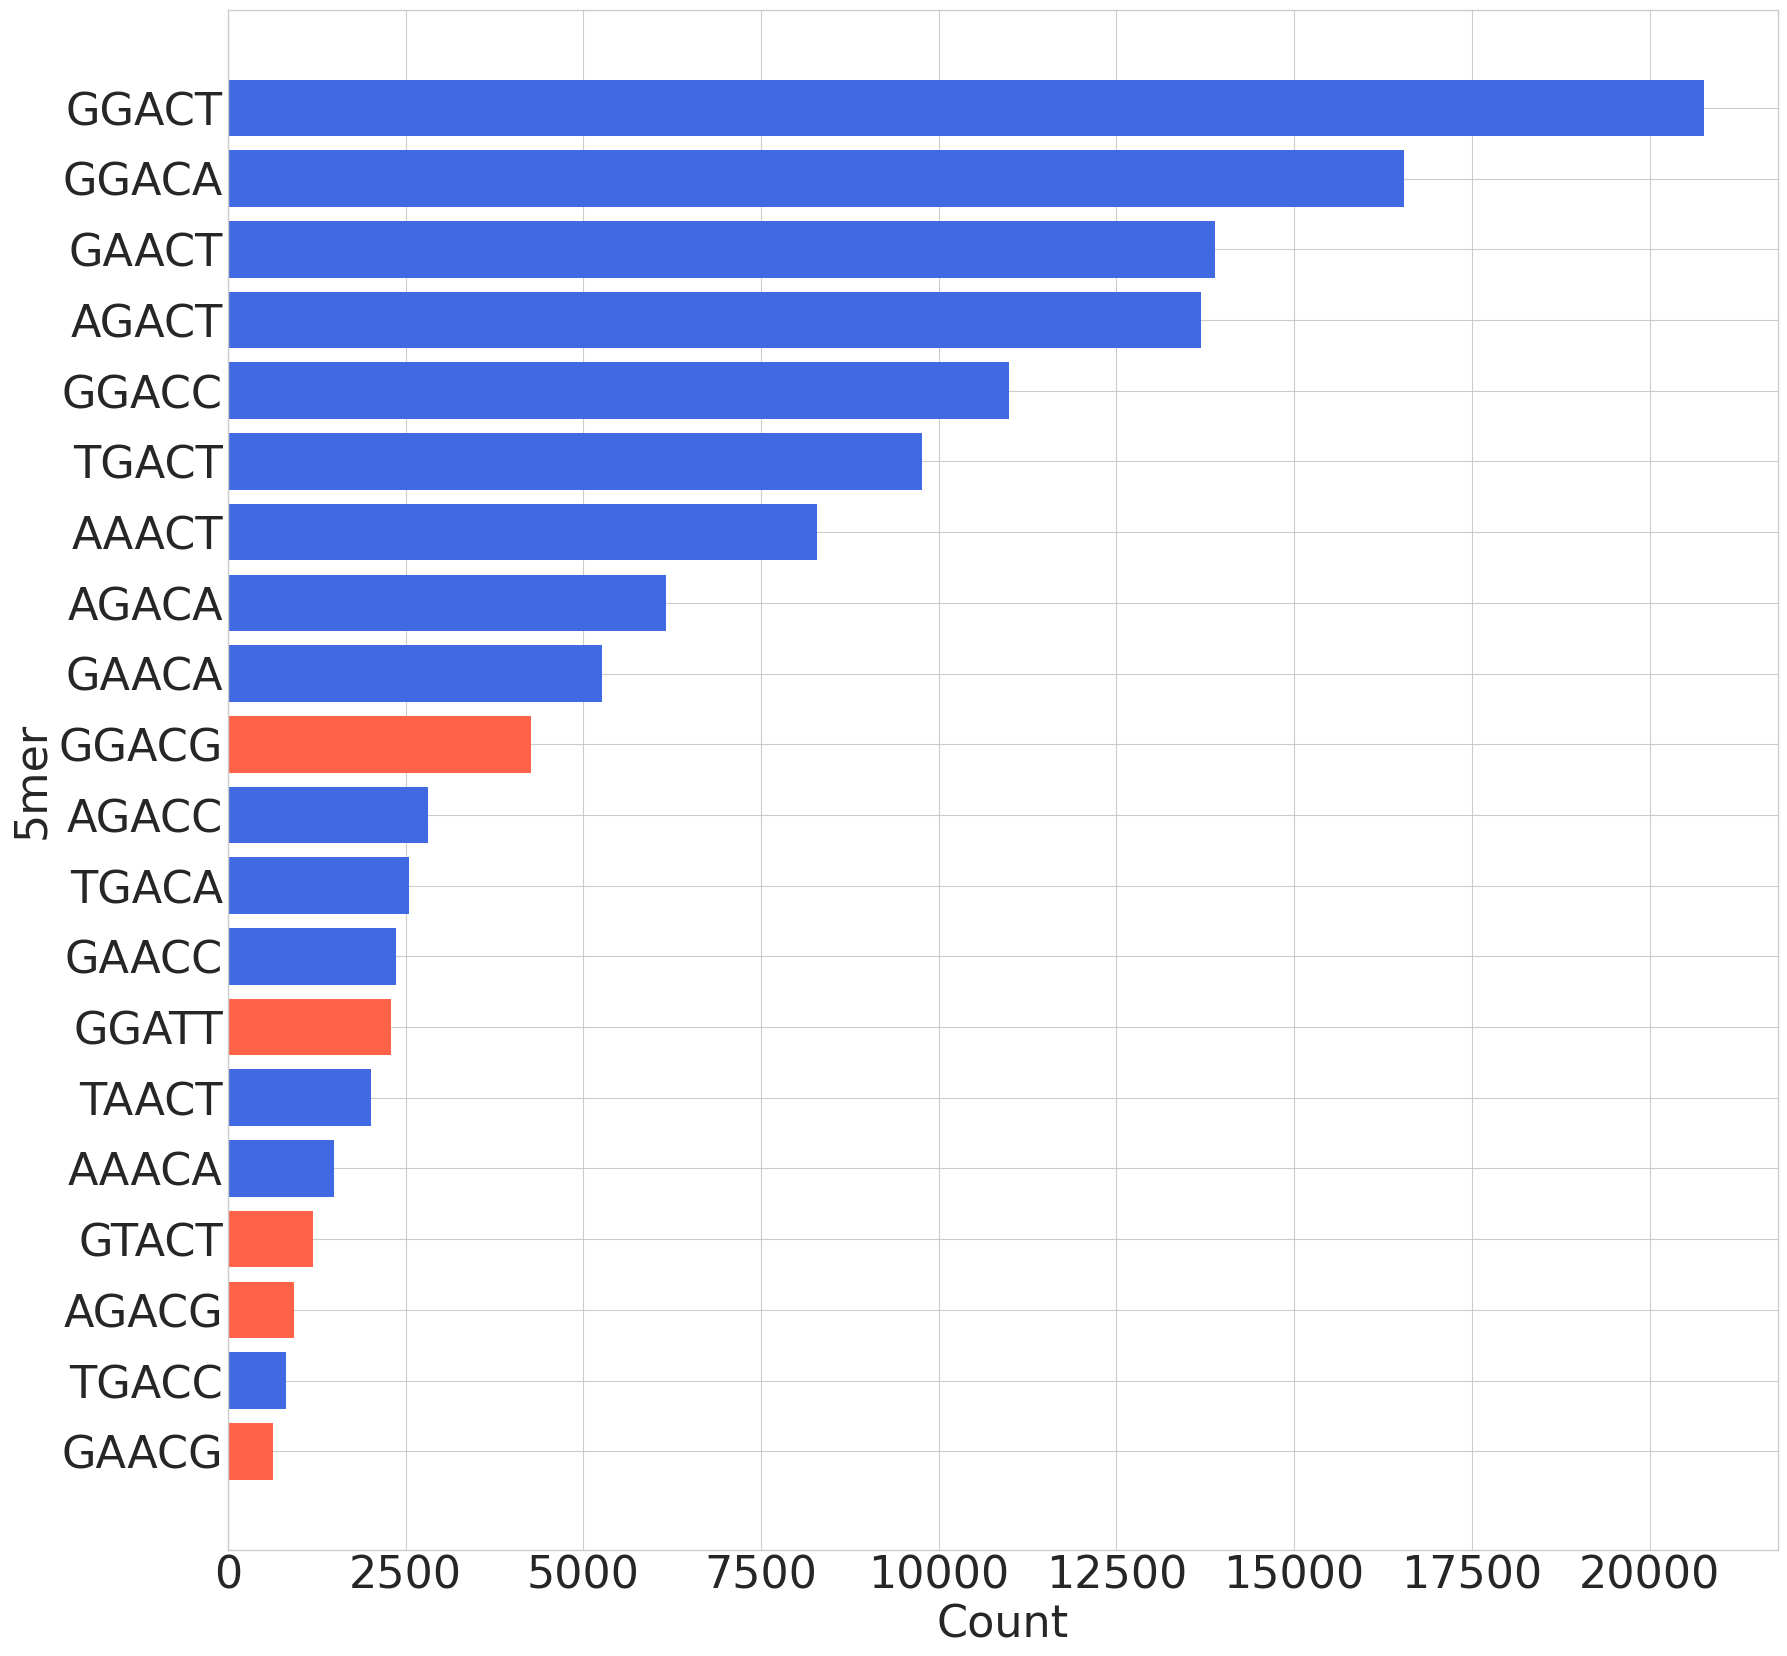

In [44]:
## Plot Top 20 5mers


df = hek_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hek.pdf", format="pdf")
plt.show()

     5mer  count
0   GGACT  17513
1   GGACA  13947
2   GAACT  11654
3   AGACT  11580
4   GGACC   9204
5   TGACT   8357
6   AAACT   6730
7   AGACA   5036
8   GAACA   4320
9   GGACG   3413
10  AGACC   2324
11  TGACA   2075
12  GAACC   2053
13  GGATT   1916
14  TAACT   1677
15  AAACA   1173
16  GTACT    975
17  AGACG    741
18  TGACC    712
19  CAACT    511


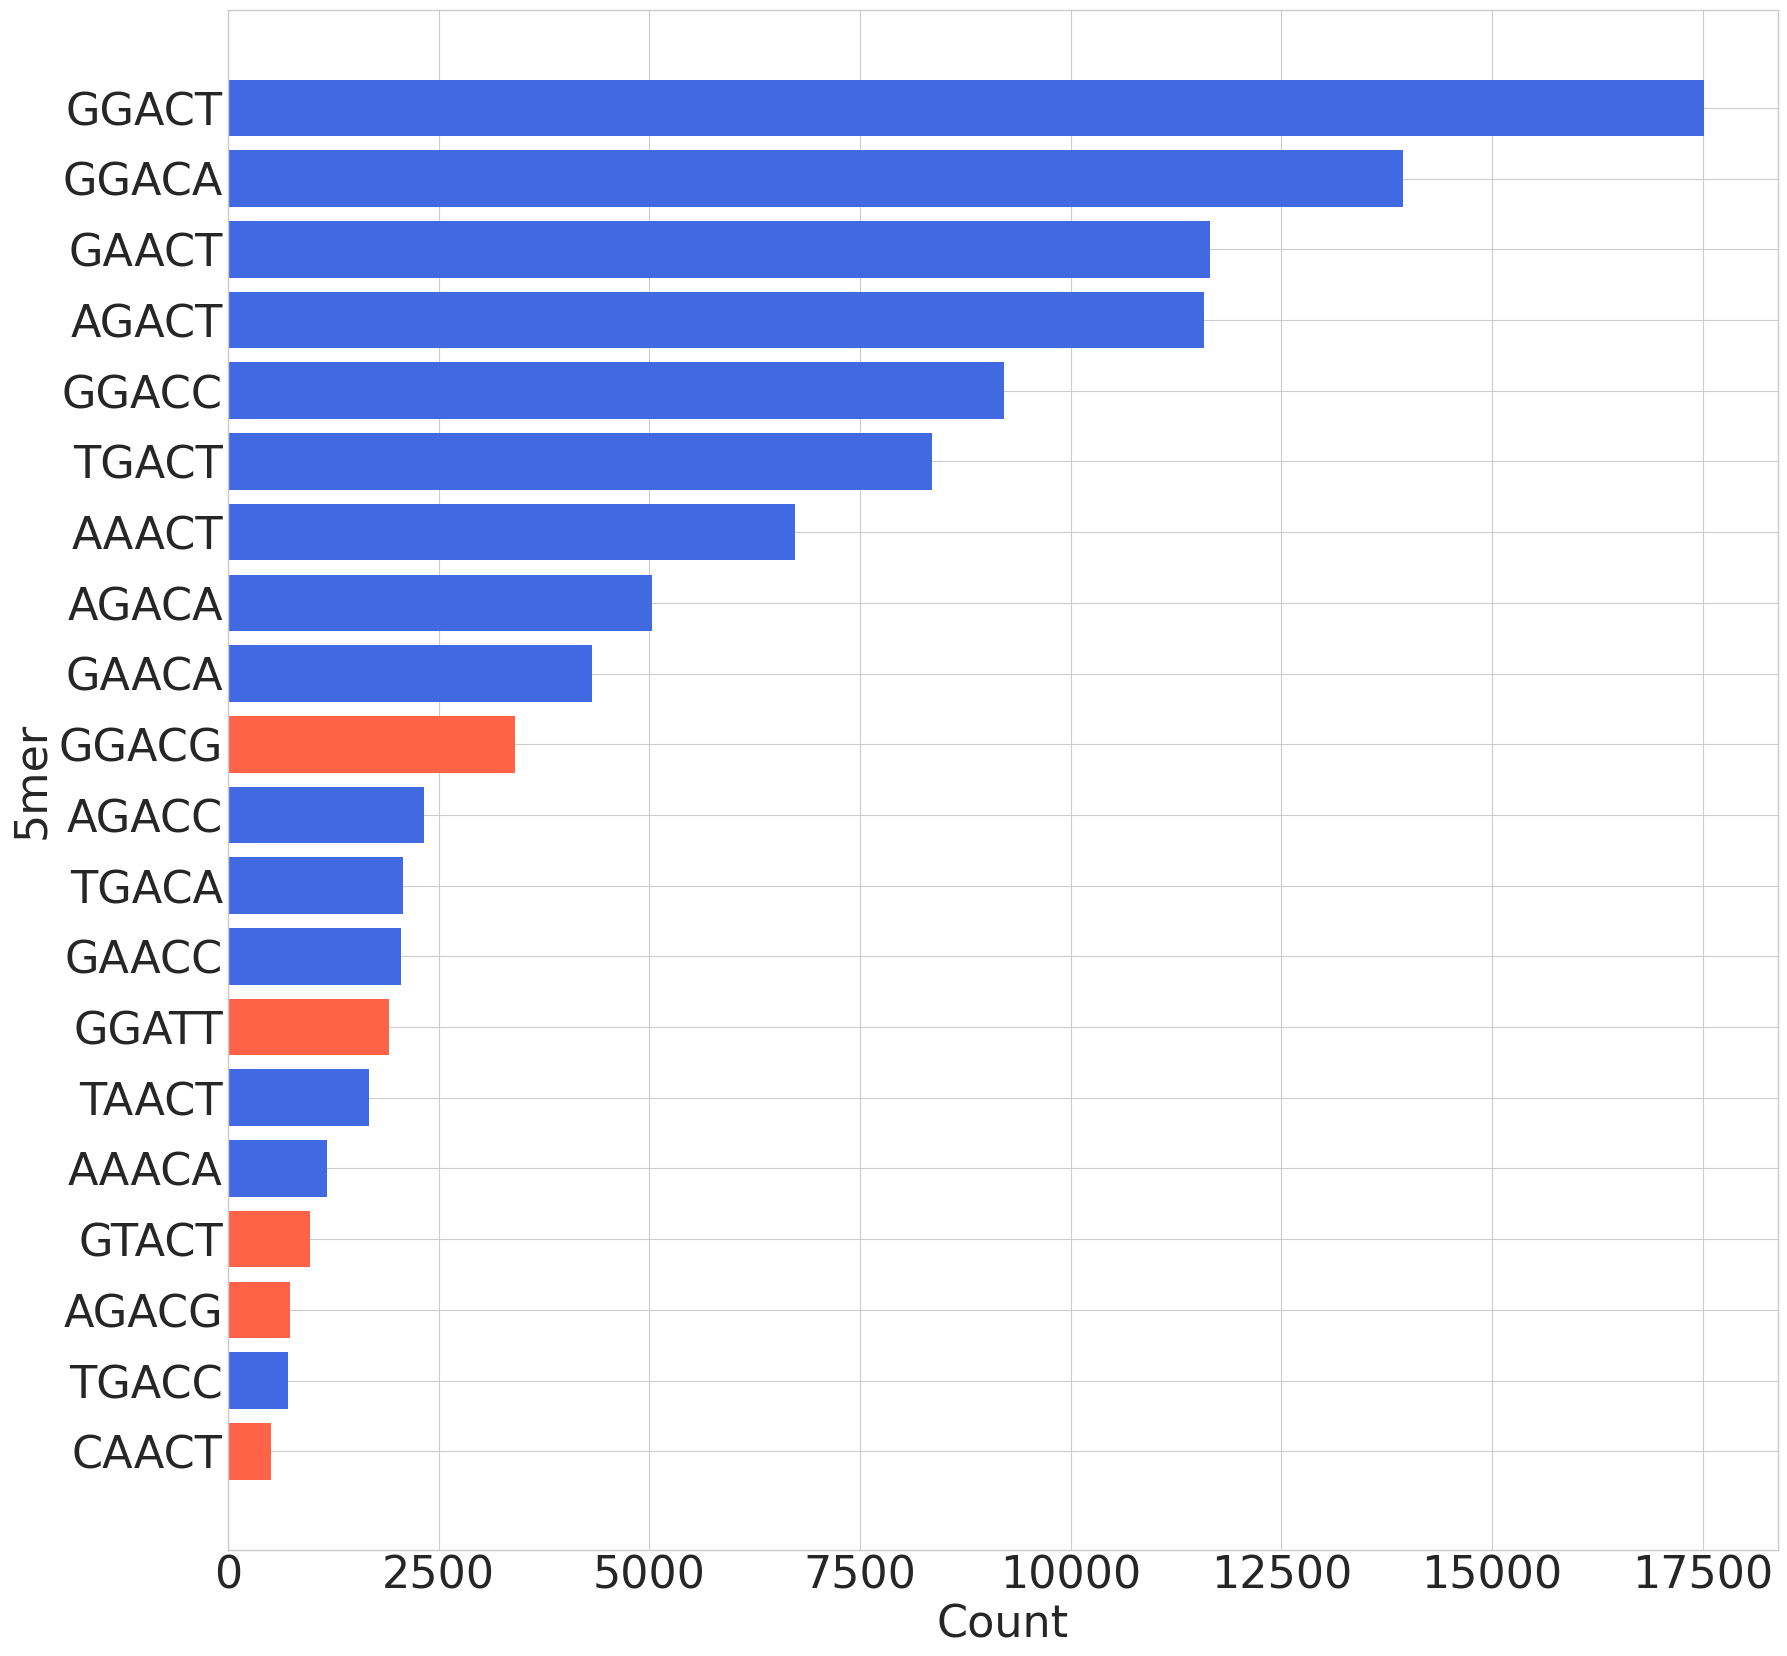

In [45]:
## Plot Top 20 5mers

df = hela_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hela.pdf", format="pdf")
plt.show()

In [46]:
import logomaker as lm
from Bio import SeqIO

Matplotlib is building the font cache; this may take a moment.


In [108]:
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/RefSeq_ENSEMBL_111224.fa"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {utils.reformat_transcript_id(x): y for x, y in fasta_dict.items()}

In [53]:
hela_m6a_transcript = hek_transcript_label.merge(hela_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")
hek_m6a_transcript = hek_transcript_label.merge(hek_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")

In [55]:
print(hela_m6a_transcript)

          transcript_id   pos base  depth   5mer  coding  drach  \
0       ENST00000002829  2600    A      5  GGACC    True   True   
1       ENST00000413852  2206    A      2  GGACC    True   True   
2       ENST00000434342  2536    A      1  GGACC    True   True   
3        NM_001318798.2  2239    A      6  GGACC    True   True   
4        NM_001318800.2  2536    A      1  GGACC    True   True   
...                 ...   ...  ...    ...    ...     ...    ...   
862298      NM_173078.5  3295    A      1  GAACA    True   True   
862299      NM_173078.5  3426    A      1  GAACA    True   True   
862300      NM_199242.3  3968    A     11  GGACA    True   True   
862301      NR_027701.1  4532    A      1  TGACA   False   True   
862302      NR_027701.1  4631    A      1  AGACA   False   True   

                    label_id  gene_id    chr strand          genome_id  
0       ENST00000002829:2600   SEMA3F   chr3      +    chr3:+:50188068  
1       ENST00000413852:2206   SEMA3F   chr3     

In [61]:
hela_m6a_transcript["motif"] = hela_m6a_transcript.apply(lambda x: fasta_dict[x["transcript_id"]].seq[x["pos"]-5:x["pos"]+6], axis=1)
hek_m6a_transcript["motif"] = hek_m6a_transcript.apply(lambda x: fasta_dict[x["transcript_id"]].seq[x["pos"]-5:x["pos"]+6], axis=1)

In [62]:
hela_m6a_genomic_9mer = hela_m6a_transcript.groupby("genome_id").agg({"motif": "unique"}).reset_index()
hek_m6a_genomic_9mer = hek_m6a_transcript.groupby("genome_id").agg({"motif": "unique"}).reset_index()

In [63]:
hela_m6a_genomic_9mer = np.concatenate(hela_m6a_genomic_9mer["motif"].values)
hek_m6a_genomic_9mer = np.concatenate(hek_m6a_genomic_9mer["motif"].values)

In [64]:
hela_m6a_genomic_9mer = pd.DataFrame(hela_m6a_genomic_9mer, columns=["motif"])
hek_m6a_genomic_9mer = pd.DataFrame(hek_m6a_genomic_9mer, columns=["motif"])

In [65]:
hela_m6a_genomic_9mer["length"] = hela_m6a_genomic_9mer["motif"].apply(len)
hela_m6a_genomic_9mer = hela_m6a_genomic_9mer[hela_m6a_genomic_9mer["length"] == 11]
hek_m6a_genomic_9mer["length"] = hek_m6a_genomic_9mer["motif"].apply(len)
hek_m6a_genomic_9mer = hek_m6a_genomic_9mer[hek_m6a_genomic_9mer["length"] == 11]

In [66]:
hela_m6a_genomic_9mer[list(range(11))] = hela_m6a_genomic_9mer.apply(lambda x: list(x["motif"]), axis=1, result_type="expand")
hek_m6a_genomic_9mer[list(range(11))] = hek_m6a_genomic_9mer.apply(lambda x: list(x["motif"]), axis=1, result_type="expand")

In [67]:
hela_logo_df = hela_m6a_genomic_9mer[list(range(11))].apply(pd.Series.value_counts).fillna(0).astype(int).T
hek_logo_df = hek_m6a_genomic_9mer[list(range(11))].apply(pd.Series.value_counts).fillna(0).astype(int).T

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


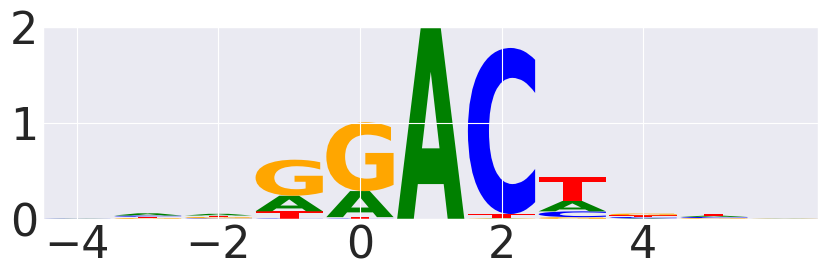

In [68]:
bit_df = hela_logo_df.copy()
bit_df.index = np.arange(11) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hela.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


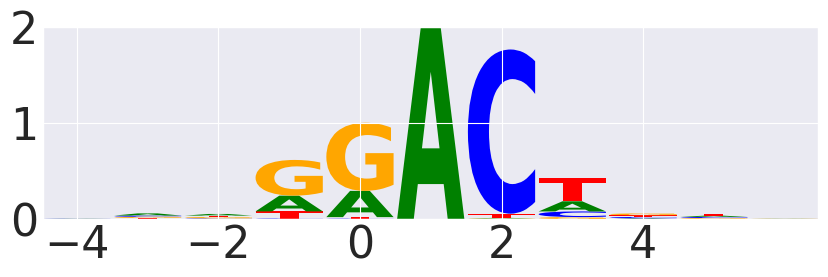

In [70]:
bit_df = hek_logo_df.copy()
bit_df.index = np.arange(11) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hek.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


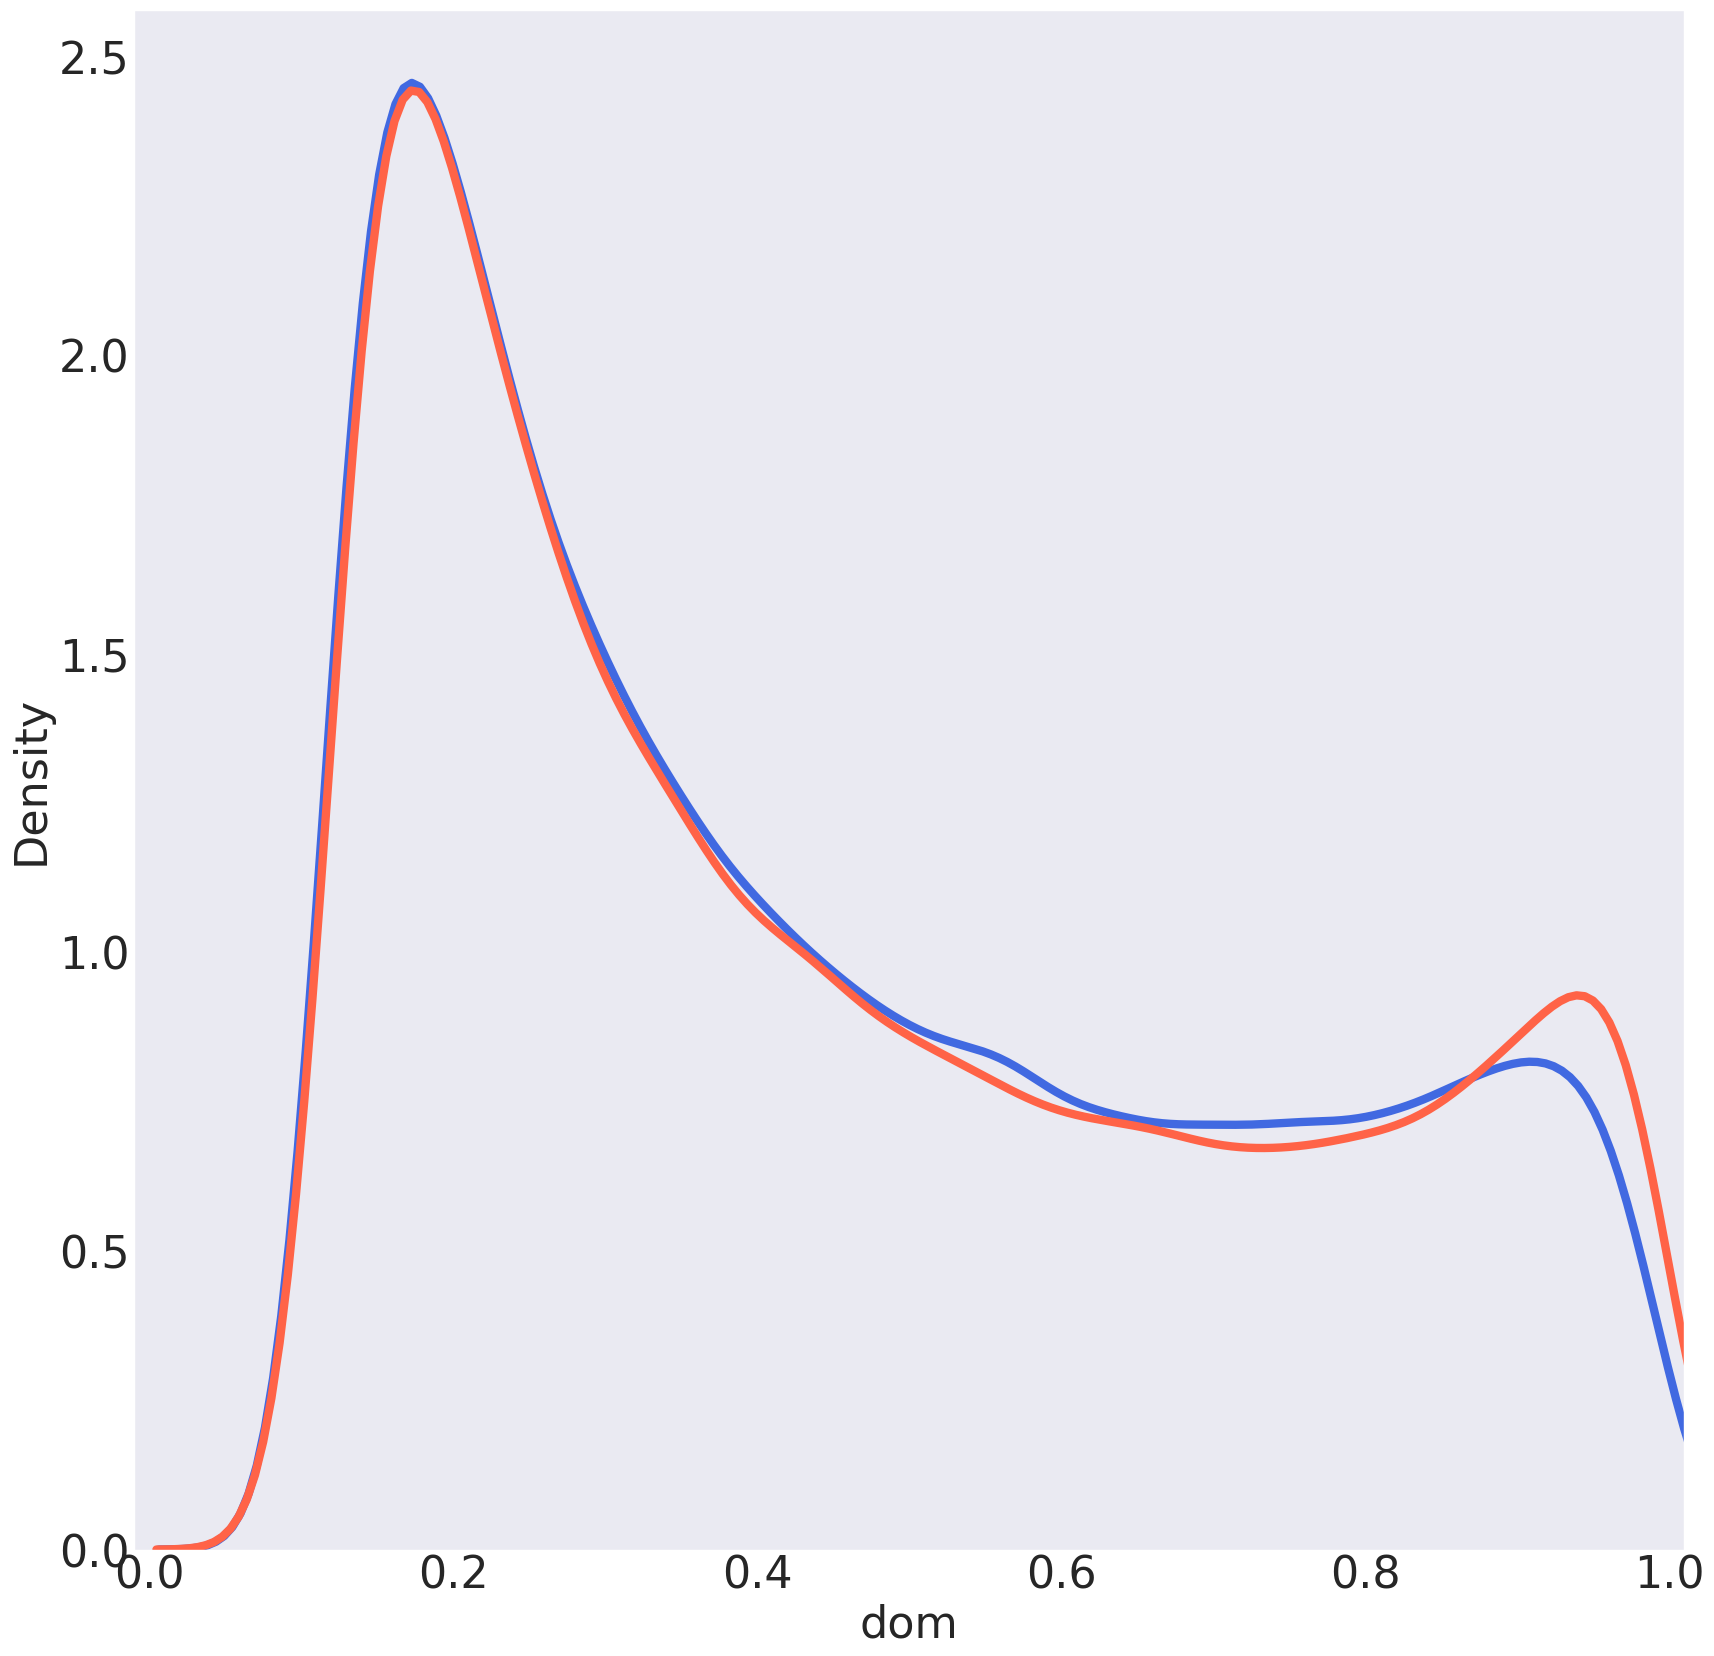

In [71]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval, x="dom", ax=ax, fill=False, levels=100, color="royalblue", alpha=1.0)
sns.kdeplot(data=hela_eval, x="dom", ax=ax, fill=False, levels=100, color="tomato",  alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_distribution.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


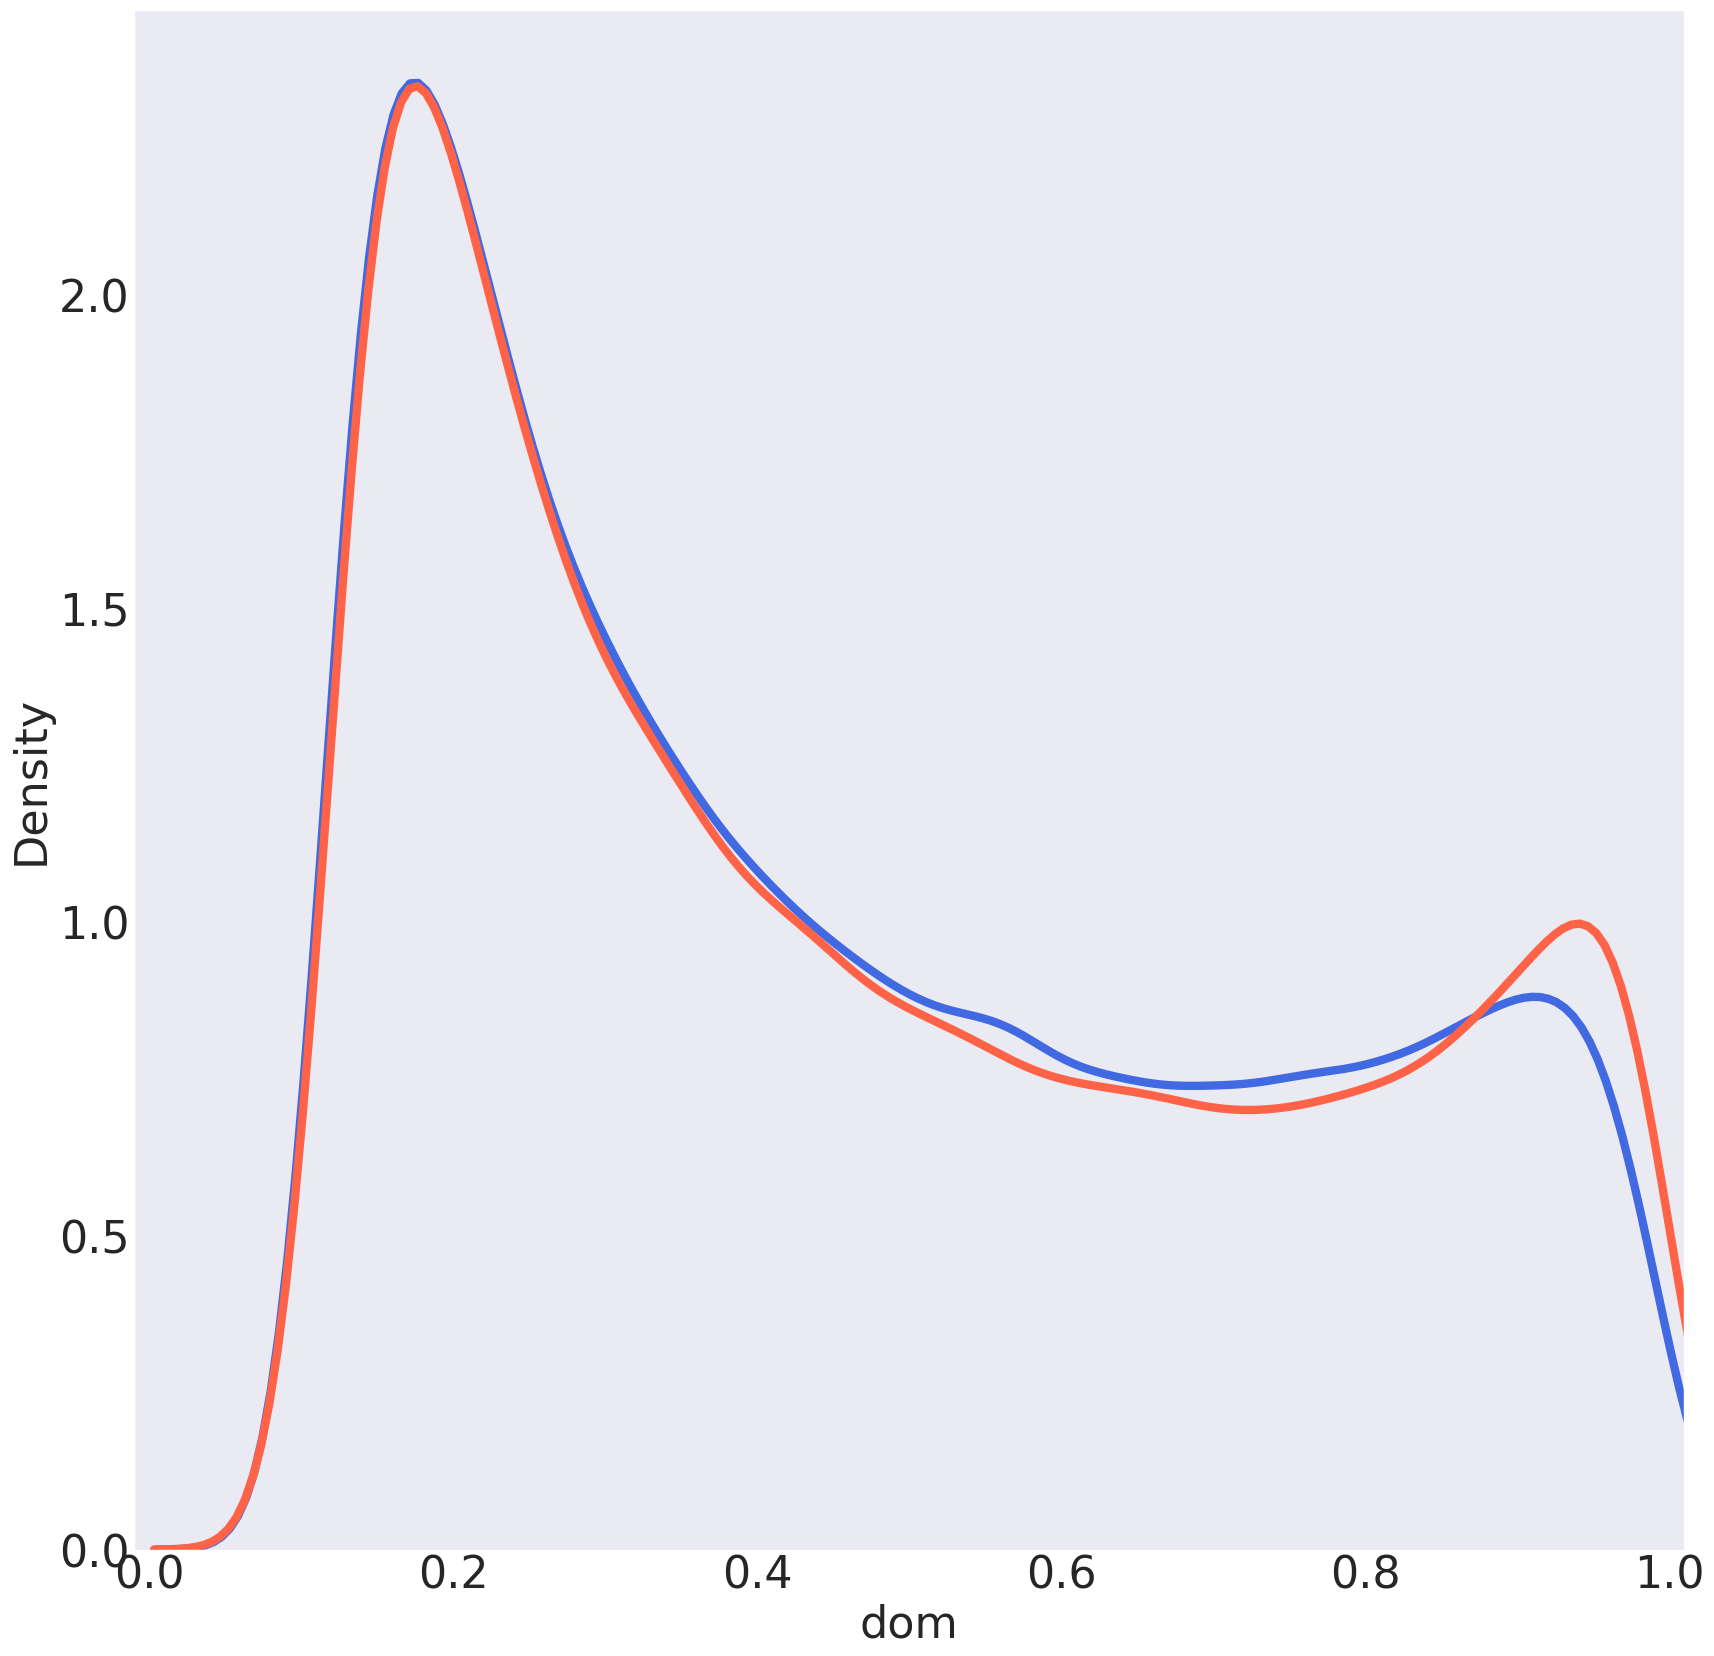

In [72]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_drach.pdf", format="pdf")
plt.show()

In [73]:
hek_eval["drach"] = hek_eval["drach"].astype(bool)
hela_eval["drach"] = hela_eval["drach"].astype(bool)

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


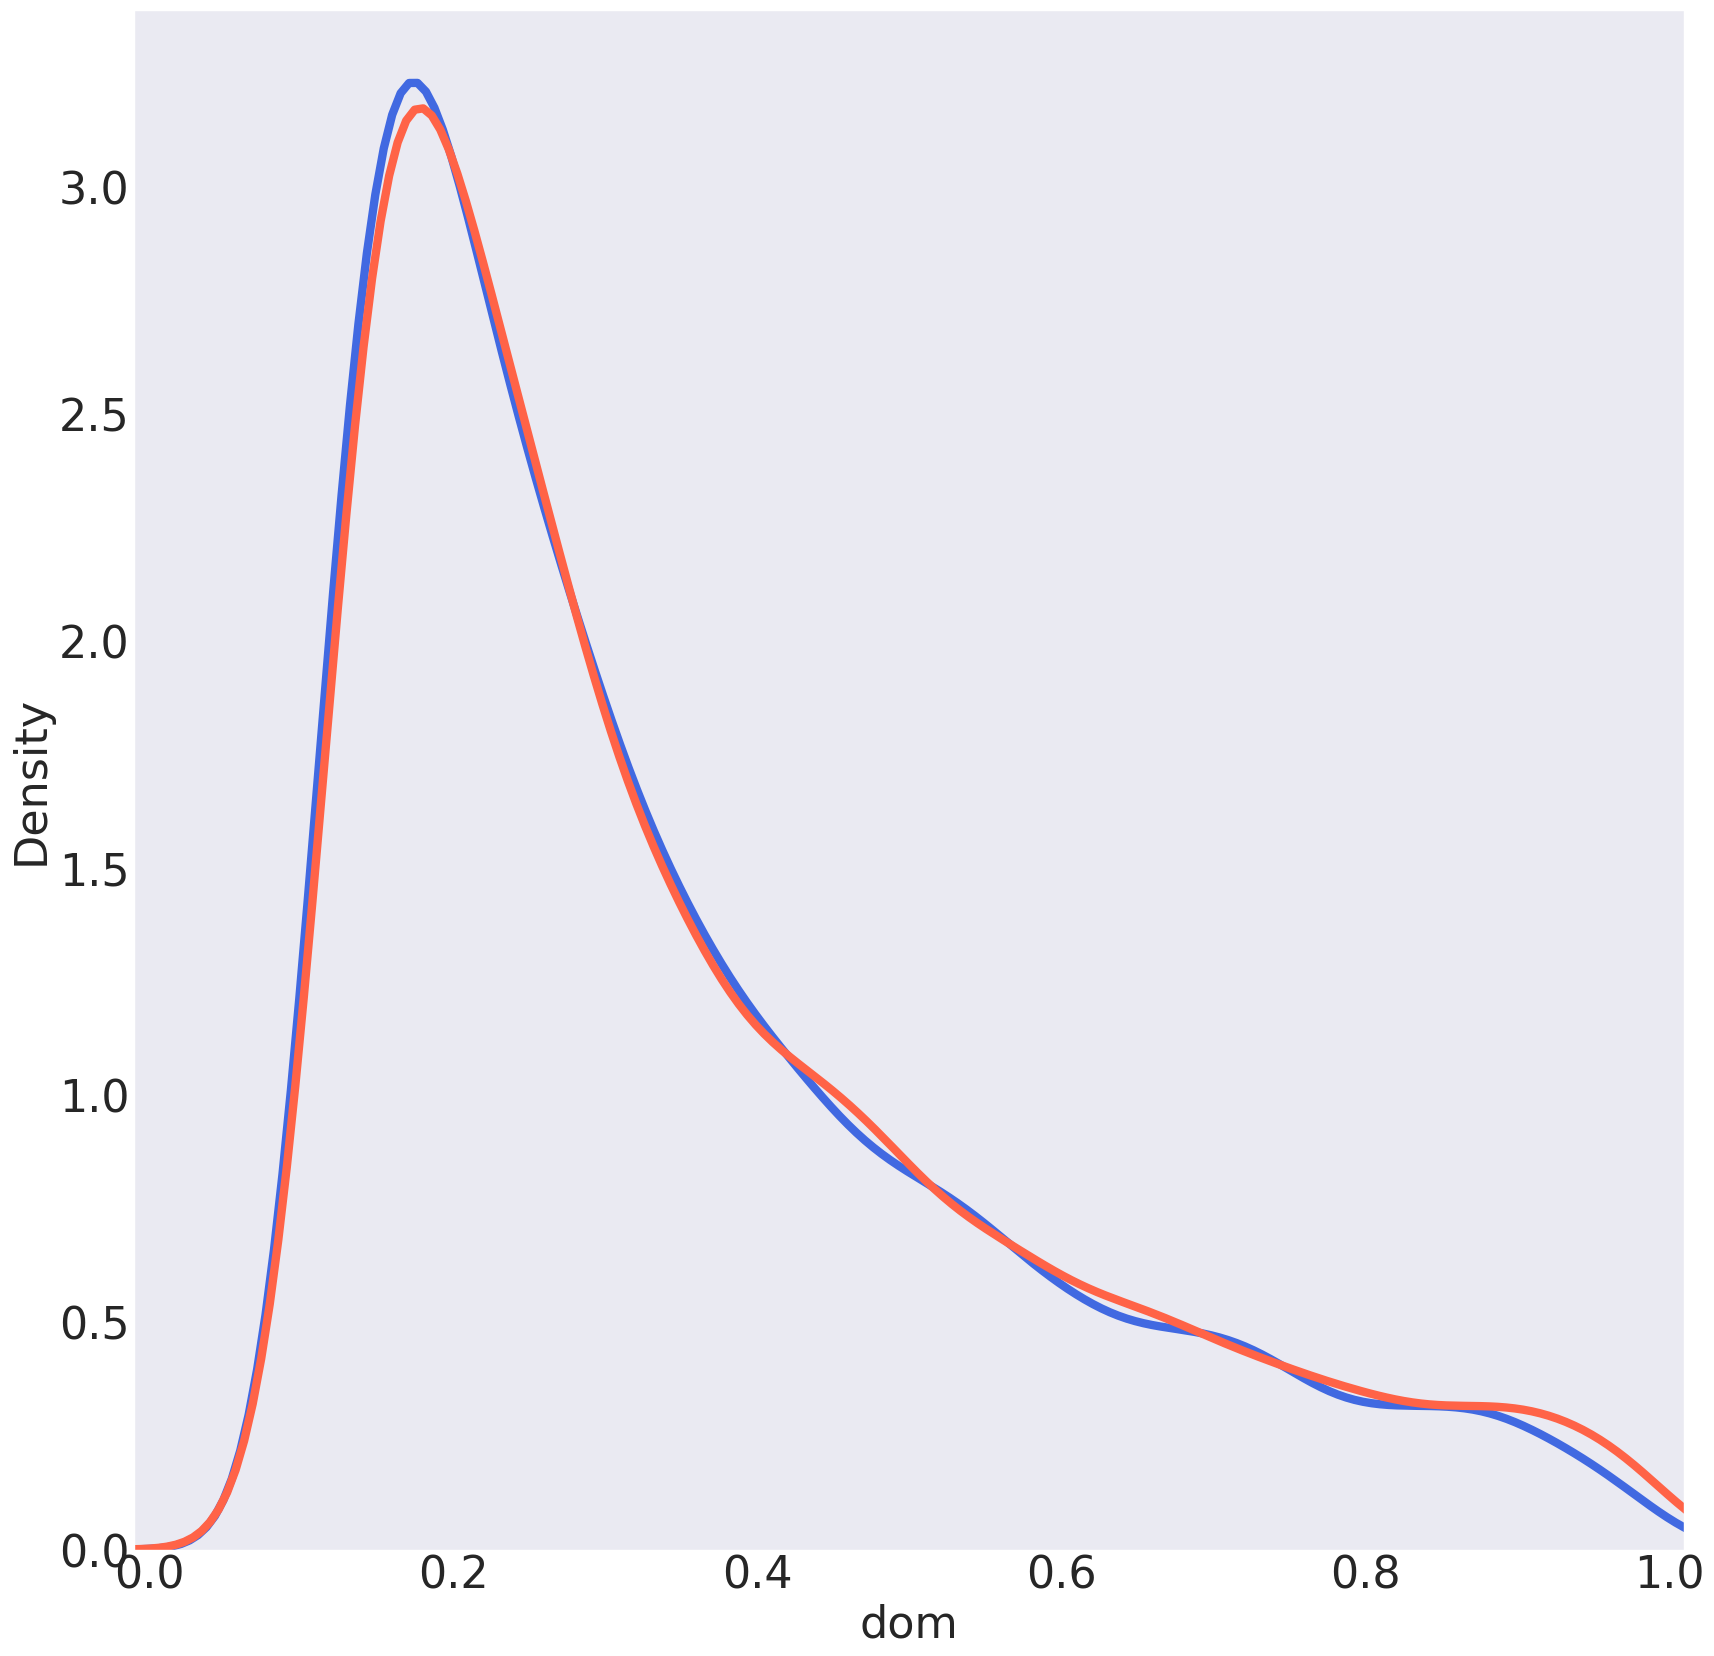

In [74]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[~hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[~hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_nondrach.pdf", format="pdf")
plt.show()

In [81]:
hela_m6a_count = hela_genomic_df_m6a.groupby("gene_symbol").size()
hek_m6a_count = hek_genomic_df_m6a.groupby("gene_symbol").size() 

print(hela_m6a_count)
print(hek_m6a_count)

gene_symbol
A4GALT    21
AACS       4
AADAT      5
AAGAB      3
AAK1       8
          ..
ZXDC      29
ZYG11A    12
ZYG11B     1
ZZEF1     26
ZZZ3      27
Length: 10452, dtype: int64
gene_symbol
A1BG         3
A1BG-AS1    18
A4GALT      19
AACS         4
AADAT        5
            ..
ZXDC        32
ZYG11A      13
ZYG11B       4
ZZEF1       27
ZZZ3        29
Length: 11730, dtype: int64


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


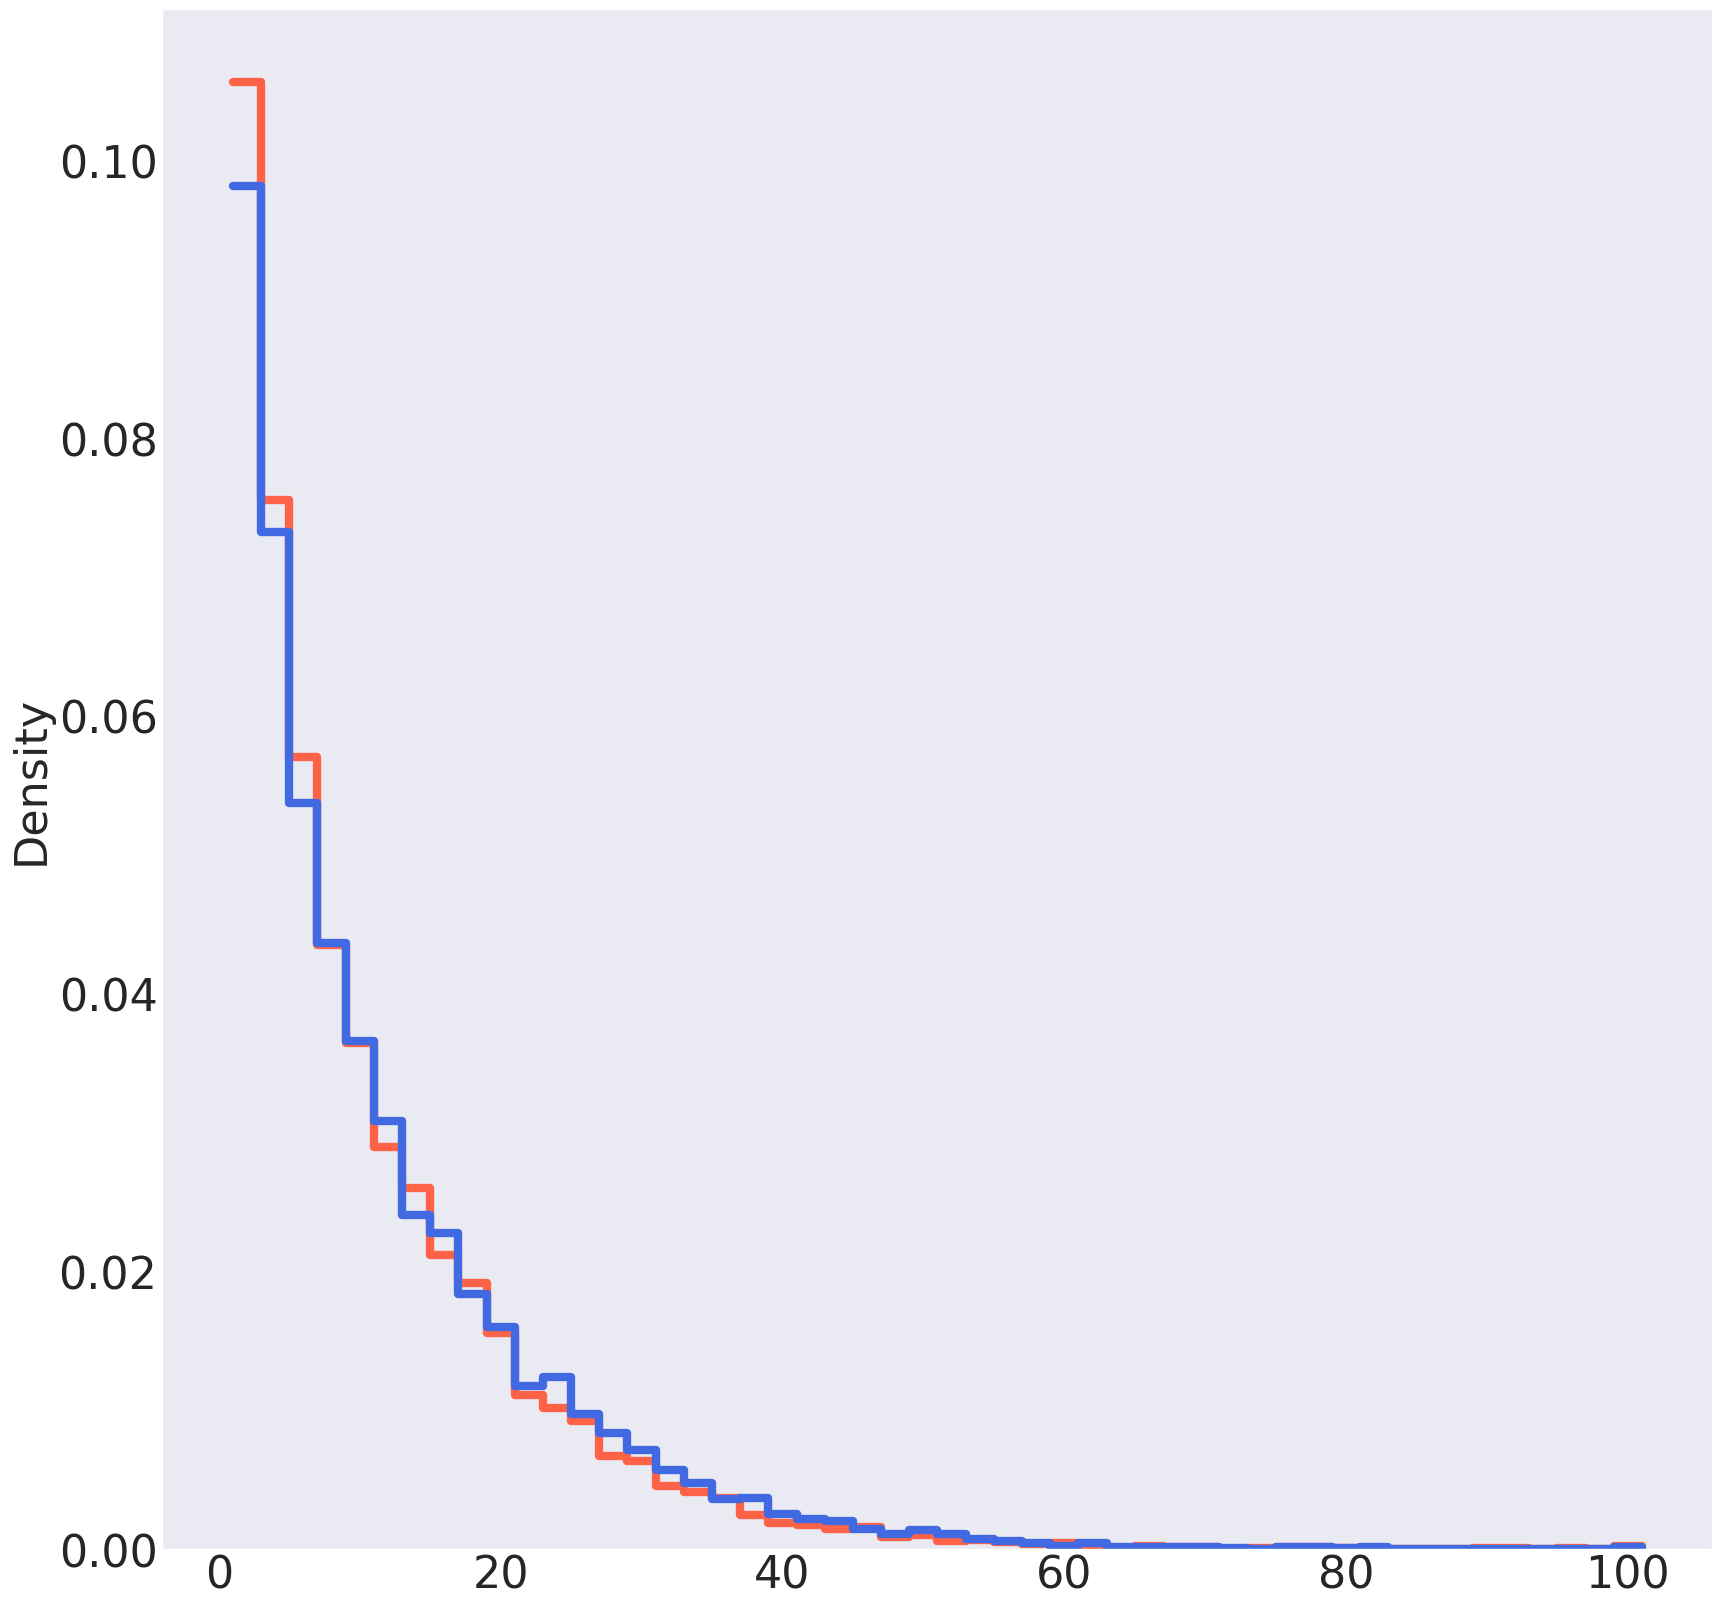

In [82]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_m6a_count, 0, 100), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_m6a_count,  0, 100), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [83]:
## How many genes have> 30 m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 20])/len(hela_m6a_count))
print(len(hek_m6a_count[hek_m6a_count  > 20])/len(hek_m6a_count))

0.1417910447761194
0.16521739130434782


In [84]:
## How many genes have m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 0])/hela_genomic_df["gene_symbol"].nunique())
print(len(hek_m6a_count[hek_m6a_count > 0])/hek_genomic_df["gene_symbol"].nunique())

0.8654467168998924
0.8654271801682161


In [85]:
## Average number of m6A sites per gene
print(hela_m6a_count.mean())
print(hek_m6a_count.mean())

10.532529659395331
11.268030690537085


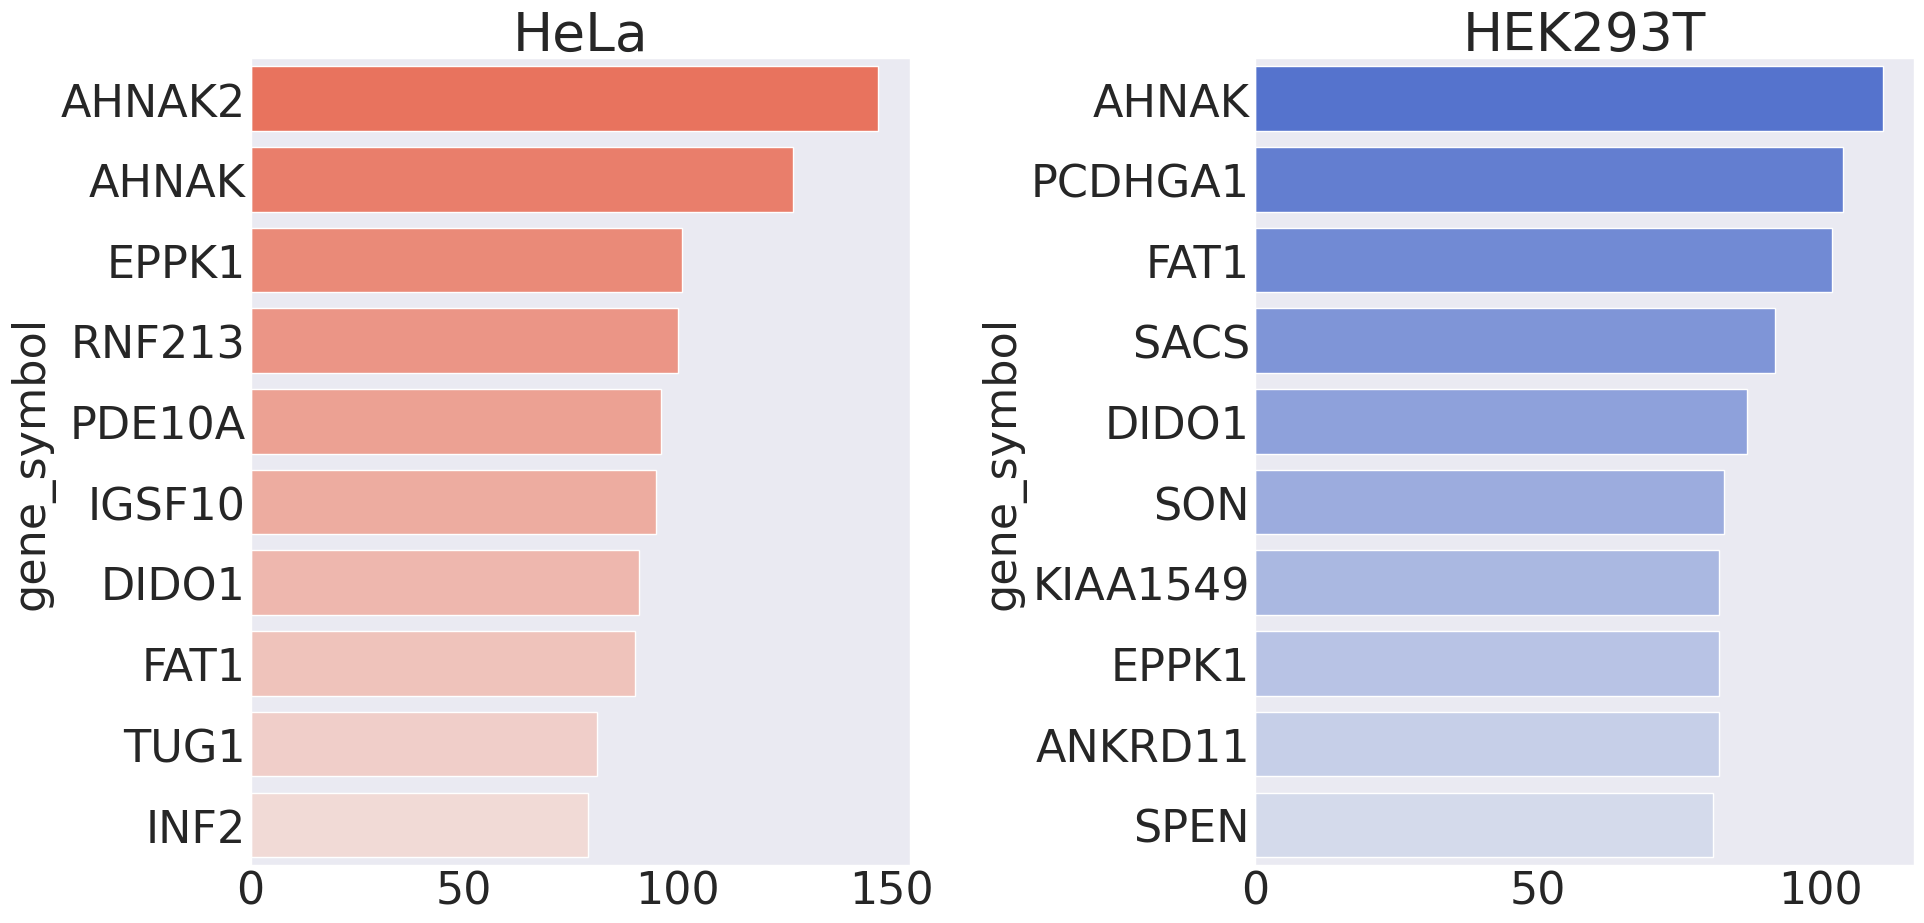

In [86]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_m6a_count.sort_values(ascending=False)
hek_arr = hek_m6a_count.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [87]:
##print top10 genes

print("\n".join(hela_arr[:100].index))
print("")
print("\n".join(hek_arr[:100].index))

AHNAK2
AHNAK
EPPK1
RNF213
PDE10A
IGSF10
DIDO1
FAT1
TUG1
INF2
ANKRD11
SON
KIAA1549
TBC1D16
ENSG00000225614
HSF2BP
PLEC
PCAT2
ZCCHC14
CELSR1
SLITRK5
ZNF646
MKI67
ERC1
CHSY3
SMCR8
PRECSIT
ARHGAP35
FAT4
ZBTB38
NSD1
IRS1
OPN3
LOC124901161
KIF1B
MGA
MYORG
SPEN
KCNQ1OT1
KMT5B
MPRIP
PHF3
ZNF318
MYOCD
ASXL1
NRIP1
ING5
SLITRK4
SLC35E1
MICAL3
ZFP62
DISP1
KLHL5
TANC2
AHDC1
GLI2
IGF1R
ZHX3
CHST3
COA1
CELSR3
ADNP2
CELSR2
C15orf39
PKD1
TASOR2
ZBED4
LOC107985871
ZNF142
ZKSCAN1
TMEM184A
MUC16
LOC105371059
FOXK2
TSHZ1
RBM12B
RANBP6
TENM3
SRCAP
SACS
ZNF12
CENPF
DNAH17-AS1
RAI1
ERMP1
MFAP3
BCL9L
LINC01297-DUXAP10-NBEAP6
SEC16A
ZNF445
LOC100129034
ARHGAP21
ZFP64
CDK13
MN1
PRAG1
SH3PXD2A
AHRR
LOC105372639
TCF20

AHNAK
PCDHGA1
FAT1
SACS
DIDO1
SON
KIAA1549
EPPK1
ANKRD11
SPEN
TUG1
PEAK1
FAT4
H4C15
ANKRD33B
TBC1D16
MKI67
ING5
H6PD
SMCR8
ARHGAP35
KMT2A
PLXNA2
CELSR2
LOC124901161
ZNF646
JCAD
PLEC
MYORG
PCDH7
VCAN
CRIP3
CELSR1
SETX
SRCAP
OPN3
RANBP6
TASOR2
MACF1
BPTF
RESF1
ZBTB38
ERC1
ZNF544
ZCCHC14
LINC00205
IRS1

In [98]:
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}
## Draw Discrepancy
refflat_df = utils.parse_refflat_v2()
convert_dict = dict(zip(refflat_df["transcript_id"], refflat_df["gene_id"]))
a_count_df = pd.DataFrame(a_count_dict.items(), columns=["transcript_id", "a_count"])
a_count_df["gene_id"] = a_count_df["transcript_id"].map(convert_dict)
a_count_df = a_count_df.groupby("gene_id").agg({"a_count": "mean"})


In [99]:
hela_m6a_df = hela_df[hela_df["pm6a"] > hela_fdr_threshold]
hek_m6a_df = hek_df[hek_df["pm6a"] > hek_fdr_threshold]
hela_count_df = pd.DataFrame(hela_m6a_df["transcript_id"].value_counts())
hek_count_df = pd.DataFrame(hek_m6a_df["transcript_id"].value_counts())

hela_count_df["a_count"] = hela_count_df.index.map(a_count_dict)
hek_count_df["a_count"] = hek_count_df.index.map(a_count_dict)

hela_count_df["density"] = hela_count_df["count"]/hela_count_df["a_count"]
hek_count_df["density"] = hek_count_df["count"]/hek_count_df["a_count"]

hela_count_df["gene_id"] = hela_count_df.index.map(convert_dict)
hek_count_df["gene_id"] = hek_count_df.index.map(convert_dict)

print(hela_count_df)
print(hek_count_df)

                 count  a_count   density gene_id
transcript_id                                    
ENST00000333244    111     4423  0.025096  AHNAK2
NM_001350929.2     103     4406  0.023377  AHNAK2
XM_024449463.2      97     4436  0.021867  AHNAK2
XM_047448011.1      96     2802  0.034261  IGSF10
ENST00000378024     95     5444  0.017450   AHNAK
...                ...      ...       ...     ...
ENST00000261708      1     1182  0.000846    UTP6
ENST00000261716      1     3754  0.000266   TAOK1
ENST00000261875      1      941  0.001063   HACD3
ENST00000262039      1     2967  0.000337  PIK3C3
ENST00000749700      1      738  0.001355  FRG1HP

[23959 rows x 4 columns]
                 count  a_count   density gene_id
transcript_id                                    
NM_005245.4         86     4184  0.020554    FAT1
ENST00000644773     82     2040  0.040196    TUG1
XM_006714139.4      81     4218  0.019203    FAT1
XM_011539818.3      81     4034  0.020079   MKI67
NM_001398477.1      76  

In [100]:
## groupby gene_id, get max density, sort by density
hela_density_df = hela_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)
hek_density_df = hek_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)

print(hela_density_df)
print(hek_density_df)

                  density
gene_id                  
ADAT3            0.108911
EXD3             0.104938
MFSD5            0.096667
SDHAF1           0.088235
ENSG00000274849  0.083333
...                   ...
UBR4             0.000250
SUGT1            0.000244
LOC124900668     0.000136
SYNE2            0.000136
LOC124901725     0.000092

[9021 rows x 1 columns]
                  density
gene_id                  
EXD3             0.123457
MFSD5            0.100000
ADAT3            0.099010
MC1R             0.090674
ENSG00000260418  0.086957
...                   ...
DYNC2H1          0.000226
GUCY1A2          0.000196
NOPCHAP1         0.000171
LOC124902418     0.000110
LOC124902998     0.000017

[10293 rows x 1 columns]


In [101]:
print(", ".join(hek_density_df.index[:100]))

EXD3, MFSD5, ADAT3, MC1R, ENSG00000260418, SDHAF1, PWWP2B, HPS6, LRFN4, ENSG00000275719, UFSP1, TMEM121, ENSG00000276131, FJX1, FAM110A, OXLD1, TIMM29, KCNJ4, NCBP2AS2, B3GALT6, SCO2, LARRPM, IMP3, SSR4P1, UQCC4, C19orf73, ENSG00000274425, ENSG00000288187, HDHD3, TMEM115, C11orf68, LRFN1, C15orf39, LOC642361, PYGO2-AS1, TMEM177, KTI12, TMEM203, OXCT2, TRABD-AS1, SLC25A29, ASH1L-AS1, ZNF865, CHST14, RPRML, BLOC1S4, PLEKHF1, RNU6-8, LRFN3, RNF26, DOLK, ZNF581, GFOD2, FRAT1, ADORA2B, ABHD15, WDR6, LINC02593, URGCP, ENSG00000259985, LPAR2, ENSG00000272599, CEBPA-DT, RAB40C, TMEM276, FKRP, KCNG1, CPTP, ENSG00000270175, MILIP, FNDC10, BORCS6, CITED4, CANT1, EMILIN3, UBALD1, LRRN2, TUSC1, ENSG00000304289, ING5, SNX5, OXR1, CYBC1, LINC01389, DEXI, FRAT2, RTN4R, ARL4D, SLC66A2, HOXD4, NUDT19-DT, KLHL25, FBXO46, ENSG00000286388, LINC00339, ARFGAP1, ZBED1, ENSG00000271737, DEDD2, FOXO6


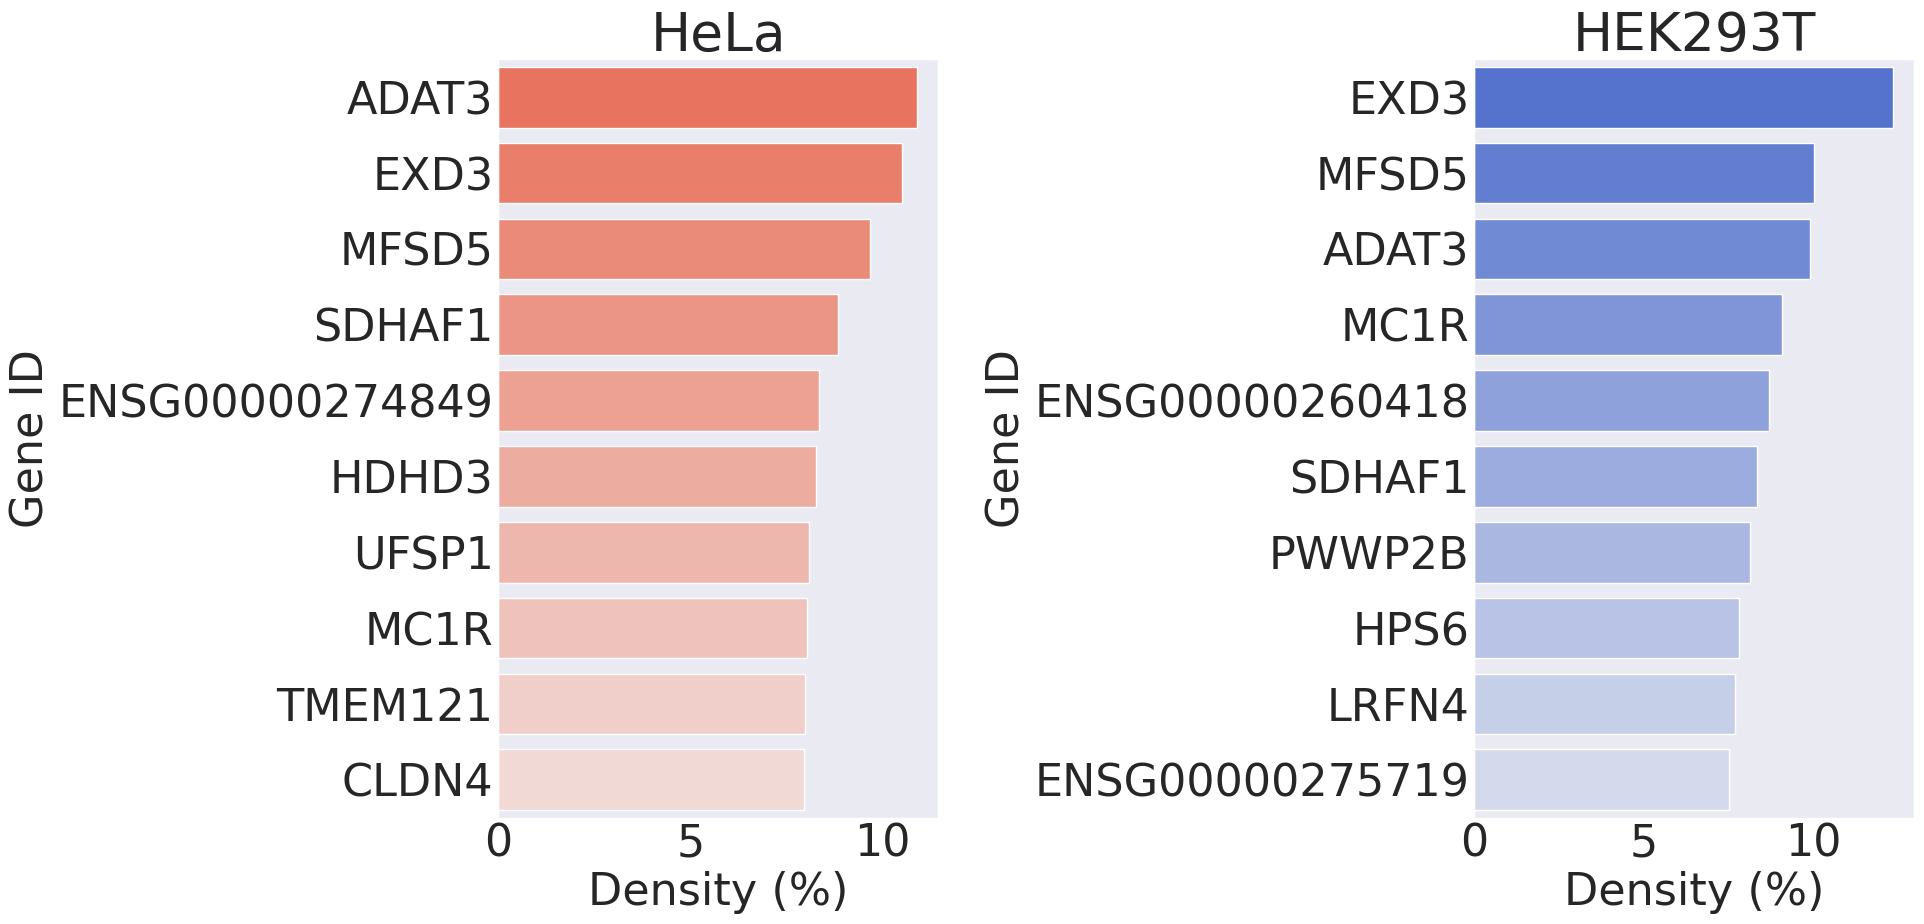

In [102]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
## Vertical bar plot
sns.barplot(x=hela_density_df[:10]["density"]*100, y=hela_density_df[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_density_df[:10]["density"]*100, y=hek_density_df[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
ax[0].set_xlabel("Density (%)")
ax[1].set_xlabel("Density (%)")
ax[0].set_ylabel("Gene ID")
ax[1].set_ylabel("Gene ID")
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [103]:
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(np.int32)
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(np.int32)

In [105]:
hek_count_df = hek_df["transcript_id"].value_counts()
hela_count_df = hela_df["transcript_id"].value_counts()
hek_start_df = hek_df.groupby("transcript_id").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("transcript_id").apply(lambda x: x["pos"].min())


In [119]:
def get_utr_orf_len(exonstarts, exonends, cdsstart, cdsend, strand):

    if exonstarts[0] == cdsstart:
        utr5_len = 0
    else:
        utr5_end_idx = np.argmax(np.array(exonends) > cdsstart)
        utr5_exonstarts = exonstarts[:utr5_end_idx+1].copy()
        utr5_exonends = exonends[:utr5_end_idx+1].copy()
        utr5_exonends[-1] = cdsstart
        utr5_len = sum(np.array(utr5_exonends) - np.array(utr5_exonstarts))

        if utr5_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if exonends[-1] == cdsend:
        utr3_len = 0
    else:
        utr3_start_idx = np.argmax(np.array(exonends) >= cdsend)
        utr3_exonstarts = exonstarts[utr3_start_idx:].copy()
        utr3_exonends = exonends[utr3_start_idx:].copy()
        utr3_exonstarts[0] = cdsend
        utr3_len = sum(np.array(utr3_exonends) - np.array(utr3_exonstarts))

        if utr3_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if strand == "-":
        utr5_len, utr3_len = utr3_len, utr5_len

    tlen = sum(np.array(exonends) - np.array(exonstarts))
    orf_len = tlen - utr5_len - utr3_len
    return utr5_len, orf_len, utr3_len, tlen


In [118]:
refflat_df = utils.parse_refflat_v2()
print(len(fasta_dict))
print(len(refflat_df))

537580
542608


In [120]:
refflat_df.reset_index(inplace=True, drop=True)
refflat_df_coding = refflat_df[refflat_df["coding"]].copy()
refflat_df_coding[["utr5_len", "orf_len", "utr3_len", "tlen"]] = refflat_df.apply(lambda x: get_utr_orf_len(x["exonStarts"], x["exonEnds"], x["cdsStart"], x["cdsEnd"], x["strand"]), axis=1, result_type="expand")

In [121]:

utr_df = refflat_df_coding[refflat_df_coding[['utr5_len', 'orf_len', 'utr3_len']].min(axis=1) > 0].copy()
mean_utr5 = utr_df["utr5_len"].mean()
mean_orf = utr_df["orf_len"].mean()
mean_utr3 = utr_df["utr3_len"].mean()
mean_sum = mean_utr5 + mean_orf + mean_utr3
mean_utr5 /= mean_sum
mean_orf /= mean_sum
mean_utr3 /= mean_sum


In [122]:
def calculate_metagene(utr5_len, orf_len, utr3_len, pos, length_preset = (0.1,0.6,0.3)):
    try:
        bins = [0, utr5_len, utr5_len + orf_len, utr5_len + orf_len + utr3_len]
        length_index = np.digitize(pos, bins) -1
        return (pos - bins[length_index]) / [utr5_len, orf_len, utr3_len][length_index] * length_preset[length_index] + sum(length_preset[:length_index])
    except:
        print(utr5_len, orf_len, utr3_len, pos, length_preset)
        


In [123]:
preset = (mean_utr5, mean_orf, mean_utr3)

In [127]:
hek_m6a_df = hek_df[hek_df["pm6a"] > hek_fdr_threshold]
hek_m6a_df = hek_m6a_df.merge(refflat_df_coding[['transcript_id', 'utr5_len', 'orf_len', 'utr3_len']], on="transcript_id", how="inner")
hek_m6a_df = hek_m6a_df[hek_m6a_df["label_id"].str.startswith("NM")]
hek_m6a_df["pos"] = hek_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hek_m6a_df["metagene"] = hek_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)


1155 3264 1516 6073 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6116 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6124 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6196 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6312 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6443 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6450 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6479 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6512 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 2451 1520 5167 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 2451 1520 5210 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 2451 1520 5544 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 2451 1520 5

In [128]:
hela_m6a_df = hela_df[hela_df["pm6a"] > hela_fdr_threshold]
hela_m6a_df = hela_m6a_df.merge(refflat_df_coding[['transcript_id', 'utr5_len', 'orf_len', 'utr3_len']], on="transcript_id", how="inner")
hela_m6a_df = hela_m6a_df[hela_m6a_df["label_id"].str.startswith("NM")]
hela_m6a_df["pos"] = hela_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hela_m6a_df["metagene"] = hela_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)

0 657 3788 4488 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6073 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6124 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6196 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6312 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6450 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6512 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 6969 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
1155 3264 1516 7456 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)
0 436 3186 3654 (0.09902044167545346, 0.4844380248804062, 0.4165415334441403)


In [130]:
hek_m6a_df = hek_m6a_df.merge(hek_transcript_label[["label_id", "drach"]], on="label_id", how="inner")
hela_m6a_df = hela_m6a_df.merge(hela_transcript_label[["label_id", "drach"]], on="label_id", how="inner")

0.2090831771492958 0.6386505514383316


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


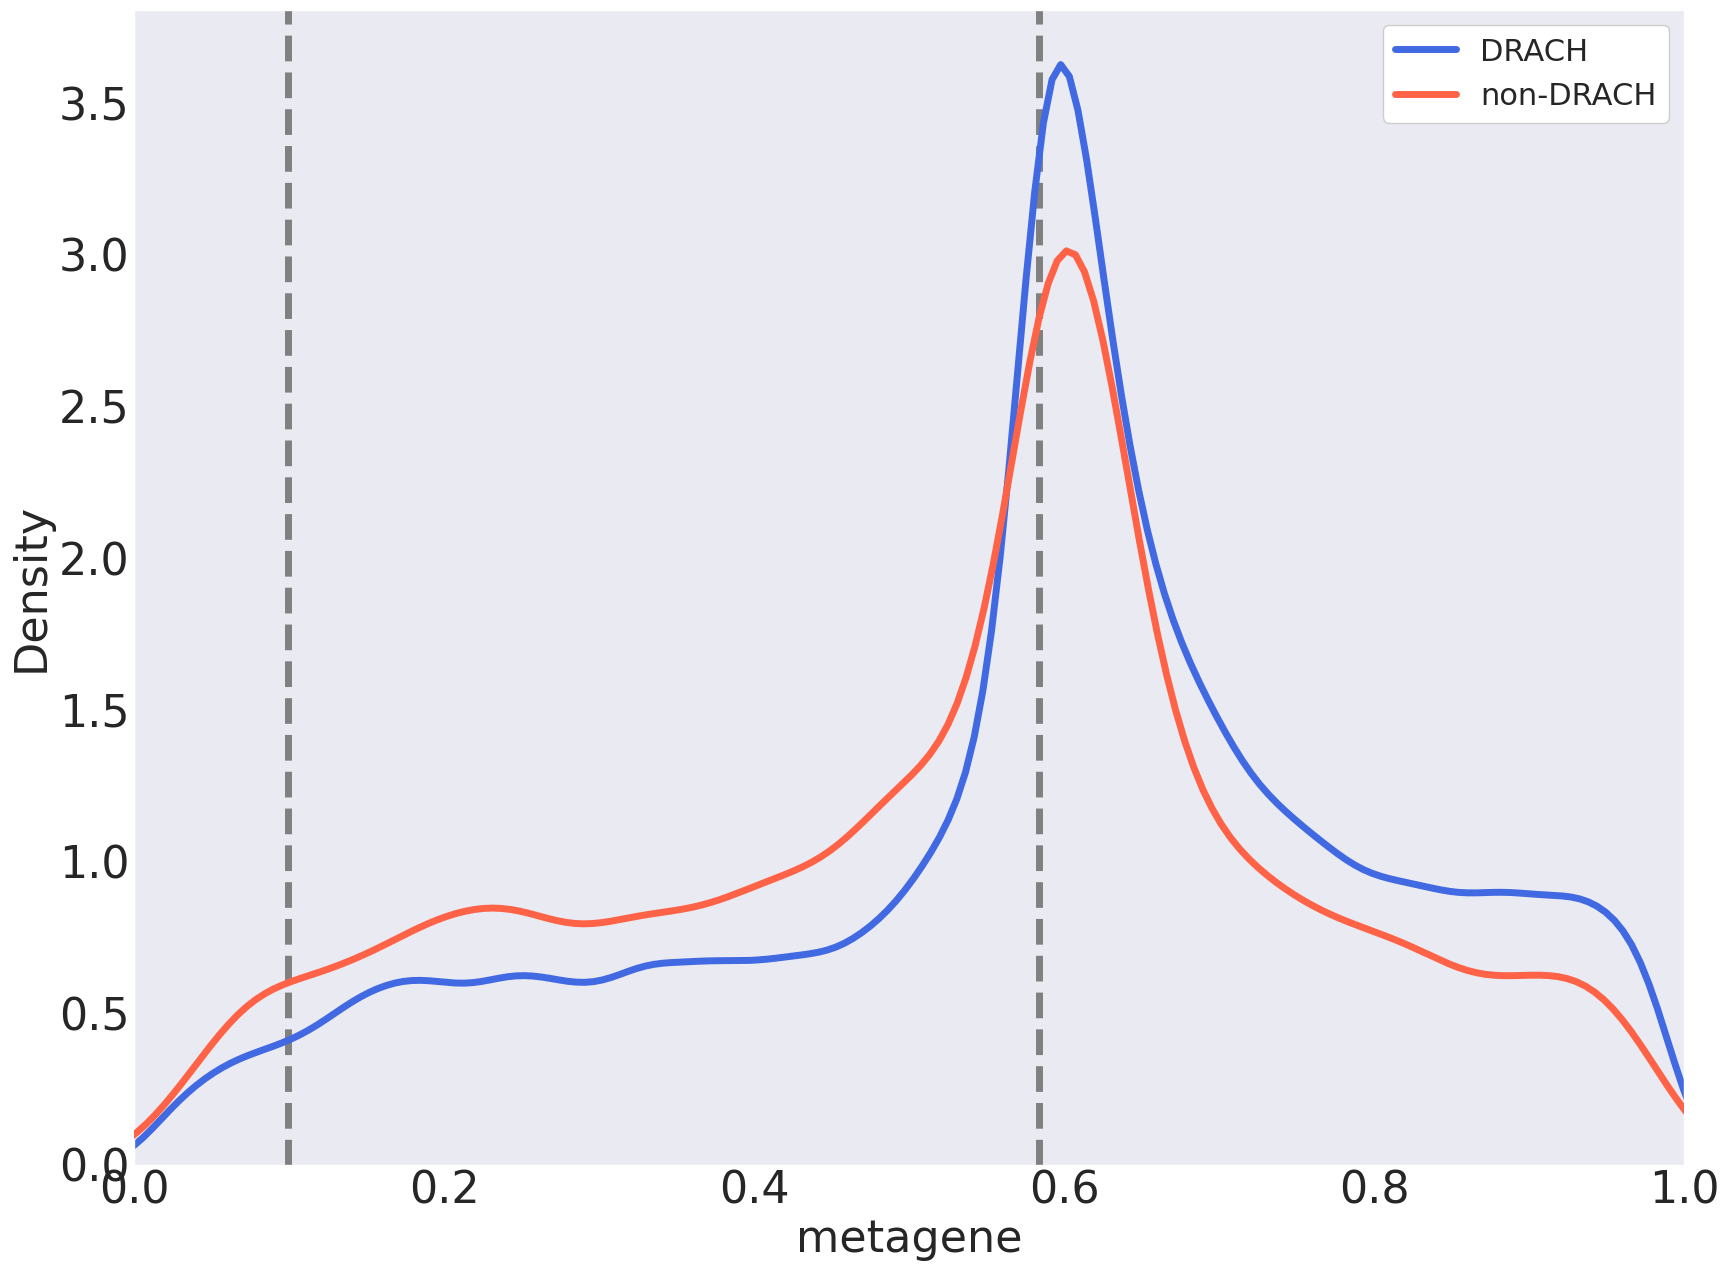

In [131]:
## Draw metagene plot
df = hek_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HEK.pdf", format="pdf")
plt.legend()
plt.show()

0.21268317103385925 0.6604174971580505


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


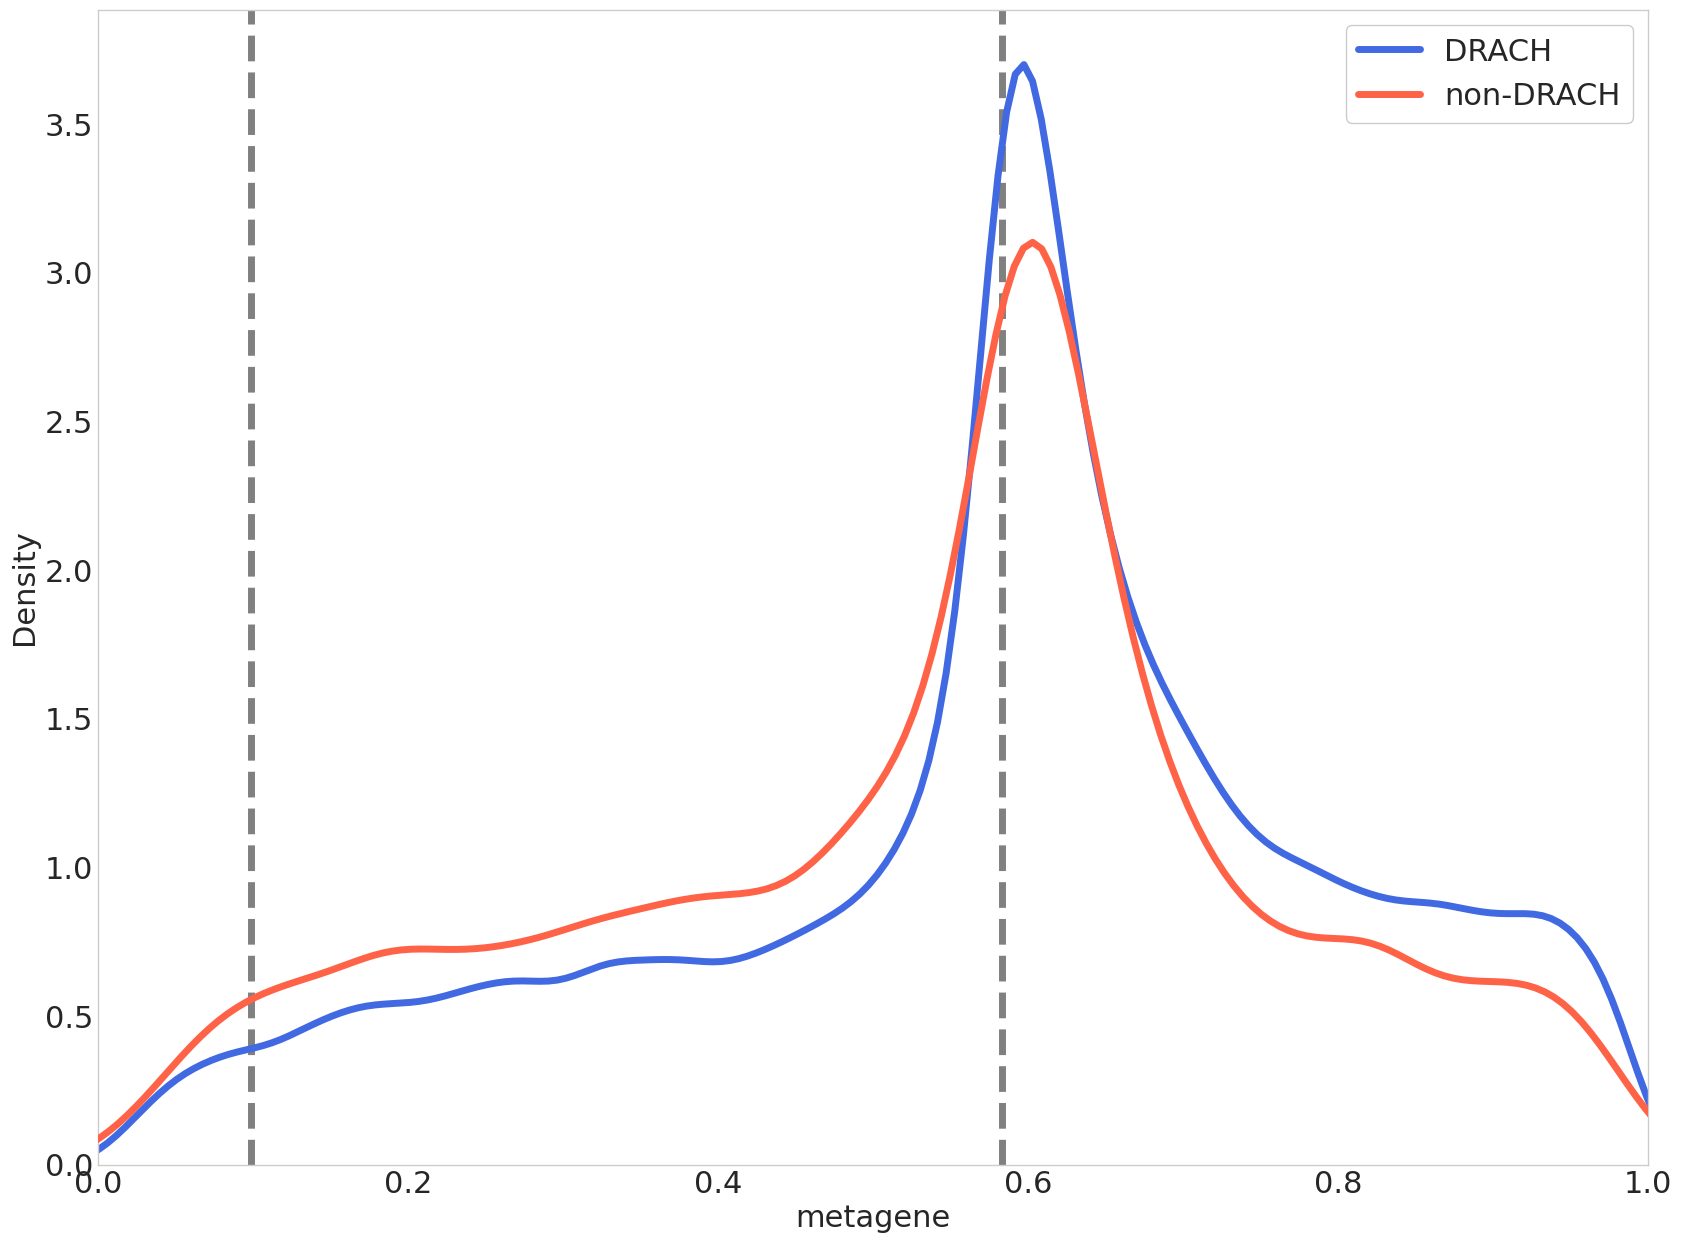

In [132]:
## Draw metagene plot
df = hela_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HeLa.pdf", format="pdf")
plt.legend()
plt.show()

In [133]:
print(hela_df)

                       label_id  pm6a       dom  count_all  count_pos  \
609           ENST00000260952:6  -0.0  0.054009         57          0   
610           ENST00000260952:7  -0.0  0.020290         59          0   
611          ENST00000260952:14  -0.0  0.000118         89          0   
612          ENST00000260952:24  -0.0  0.032300        161          0   
613          ENST00000260952:31  -0.0  0.002599        202          0   
...                         ...   ...       ...        ...        ...   
107059406  ENST00000815204:1309   0.0  0.000000         27          0   
107059407  ENST00000815204:1323  -0.0  0.025979         27          0   
107059408  ENST00000815204:1325  -0.0  0.008778         27          0   
107059409  ENST00000815204:1328   0.0  0.000000         27          0   
107059410  ENST00000815204:1330   0.0  0.000000         27          0   

           kl_div_neg  kl_div_pos  logsum_1_p_pos    transcript_id   pos  
609         42.768013    2.441718             0.